In [185]:
import os
from pathlib import Path

def encontrar_raiz_repo(marcador=".git"):
    caminho = Path.cwd()
    for pasta in [caminho, *caminho.parents]:
        if (pasta / marcador).exists():
            return pasta
    raise FileNotFoundError(f"Não achei {marcador} subindo a partir de {caminho}")

RAIZ = encontrar_raiz_repo()
print(RAIZ)

/usr/src/myapp


In [186]:
# Processamento de dados
import numpy as np
import pandas as pd
from util import utils as ut

# Graficos
import seaborn as sns
import matplotlib.pyplot as plt

# Modelos de aprendizado de máquina
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import KFold, cross_val_score, StratifiedKFold

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.preprocessing import RobustScaler

from sklearn.metrics import silhouette_score
from sklearn.metrics import calinski_harabasz_score
from sklearn.metrics import davies_bouldin_score
from sklearn.metrics import adjusted_rand_score
from sklearn.metrics import adjusted_mutual_info_score

## Carregando os dados

In [187]:
df_train = pd.read_csv(RAIZ / "data/processed/df_estruturada/df_train.csv", index_col=0)

print(df_train.shape)
df_train.head()

(4926, 11)


,pct_genes_cromossomal_efflux,mdr_score_cromossomal,mdr_score_plasmidial,pct_contigs_plasmidial,pct_plasmidial_amr,pct_plasmidial_conjugacao_amr,n_proviruses_por_mb,gc_diff_plasmid_cromossomo,virulence_score_cromossomal,virulence_score_plasmidial,cat_plasmidial_beta-lactam
sample,,,,,,,,,,,
GCA_021009385.1,7.142857,13,3,11.818182,30.769231,0.000000,1.662461,0.33,6,4,0
GCA_015825355.1,12.500000,3,0,1.666667,0.000000,0.000000,0.942911,-6.27,6,0,0
GCA_038594105.1,1.785714,12,7,14.925373,10.000000,3.333333,0.842382,-1.08,8,3,1
GCA_019201995.1,1.785714,14,5,21.487603,7.692308,0.000000,1.323753,-1.00,8,2,0
GCA_038066875.1,25.000000,4,3,25.668449,4.166667,0.000000,0.841943,-0.31,3,1,0


In [188]:
metadata_cols = pd.read_csv(RAIZ / "data/processed/metadata_filtrada.csv")

metadata_cols = metadata_cols.set_index('sample')
metadata_cols.head()

,Species,Source,Date,Location,BioSample,Estado,Região,source_type,WHO_Priority
sample,,,,,,,,,
GCA_000216055.2,Leptospira interrogans,Homo sapiens,NaN,Salvador,SAMN00254327,BA,Nordeste,Other,Other
GCA_000316425.1,Escherichia coli,NaN,1990.0,Brazil,SAMN01041333,NaN,NaN,Unknown,Critical
GCA_000223095.2,Vibrio cholerae,patient with cholera-like diarrhea,1991.0,NaN,SAMN02470783,NaN,NaN,Gastrointestinal,Other
GCA_036761135.1,Acinetobacter bereziniae,Rectal Swab,2019.0,Brazil,SAMN39408214,NaN,NaN,Gastrointestinal,Other
GCA_003670255.1,Acinetobacter bereziniae,Endotracheal aspirate,2014.0,"Londrina, PR",SAMN09907131,PR,Sul,Respiratory,Other


In [189]:
metadata_alinhado = metadata_cols.loc[df_train.index]

print(metadata_alinhado.shape)
metadata_alinhado.head()

(4926, 9)


,Species,Source,Date,Location,BioSample,Estado,Região,source_type,WHO_Priority
sample,,,,,,,,,
GCA_021009385.1,Staphylococcus aureus,Nasal Colonization,2016.0,Rio de Janeiro,SAMN16946800,RJ,Sudeste,Respiratory,High
GCA_015825355.1,Neisseria meningitidis,cerebrospinal fluid,2016.0,"Sao Paulo, Sao Paulo",SAMN10873099,SP,Sul,CNS,Other
GCA_038594105.1,Pseudomonas aeruginosa,Surveillance swab,2023.0,"Sao Paulo, Sao Paulo",SAMN40996642,SP,Sul,Other,High
GCA_019201995.1,Escherichia coli,urine,2014.0,Uberlandia,SAMN14464882,NaN,NaN,Urinary,Critical
GCA_038066875.1,Burkholderia contaminans,blood,2023.0,Sao Paulo,SAMN40603088,SP,Sul,Blood,Other


In [190]:
top_especies = metadata_alinhado["Species"].value_counts().nlargest(10).index

especie_plot_completo = metadata_alinhado["Species"].where(
    metadata_alinhado["Species"].isin(top_especies), "Outras"
)

especie_plot_completo.head()

sample
GCA_021009385.1     Staphylococcus aureus
GCA_015825355.1    Neisseria meningitidis
GCA_038594105.1    Pseudomonas aeruginosa
GCA_019201995.1          Escherichia coli
GCA_038066875.1                    Outras
Name: Species, dtype: object

## K-means

### Transformações

In [191]:
colunas_X = ['pct_genes_cromossomal_efflux', 'mdr_score_cromossomal',
       'mdr_score_plasmidial', 'pct_contigs_plasmidial', 'pct_plasmidial_amr',
       'pct_plasmidial_conjugacao_amr', 'n_proviruses_por_mb',
       'gc_diff_plasmid_cromossomo', 'virulence_score_cromossomal',
       'virulence_score_plasmidial', 'cat_plasmidial_beta-lactam']

X_base = df_train[colunas_X]

transformacoes = {
    "Sem scaling": X_base.values,
    "StandardScaler": StandardScaler().fit_transform(X_base),
    "MinMaxScaler": MinMaxScaler().fit_transform(X_base),
}

### Elbow Method

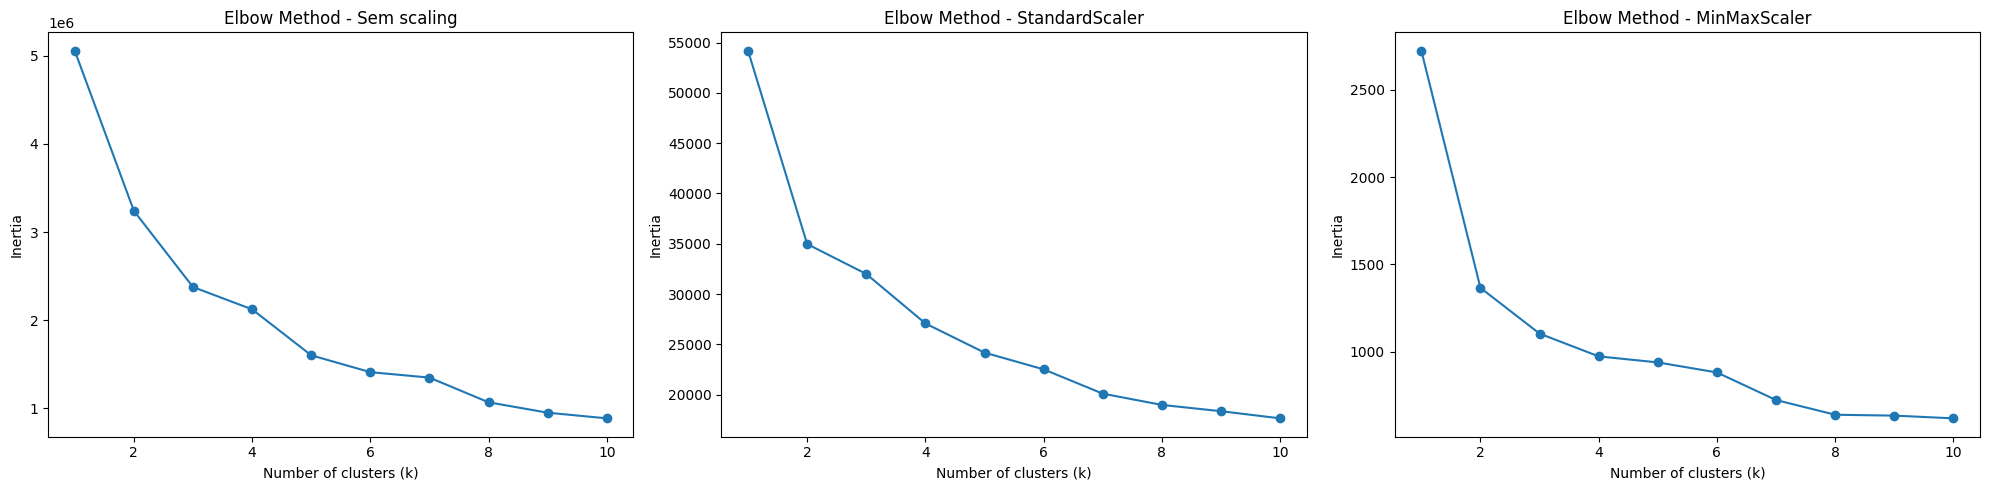

In [192]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for ax, (nome, X) in zip(axes, transformacoes.items()):
    inertia = []
    for k in range(1, 11):
        kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")
        kmeans.fit(X)
        inertia.append(kmeans.inertia_)

    ax.plot(range(1, 11), inertia, marker="o")
    ax.set_xlabel("Number of clusters (k)")
    ax.set_ylabel("Inertia")
    ax.set_title(f"Elbow Method - {nome}")

plt.tight_layout()
plt.show()

### Silhueta

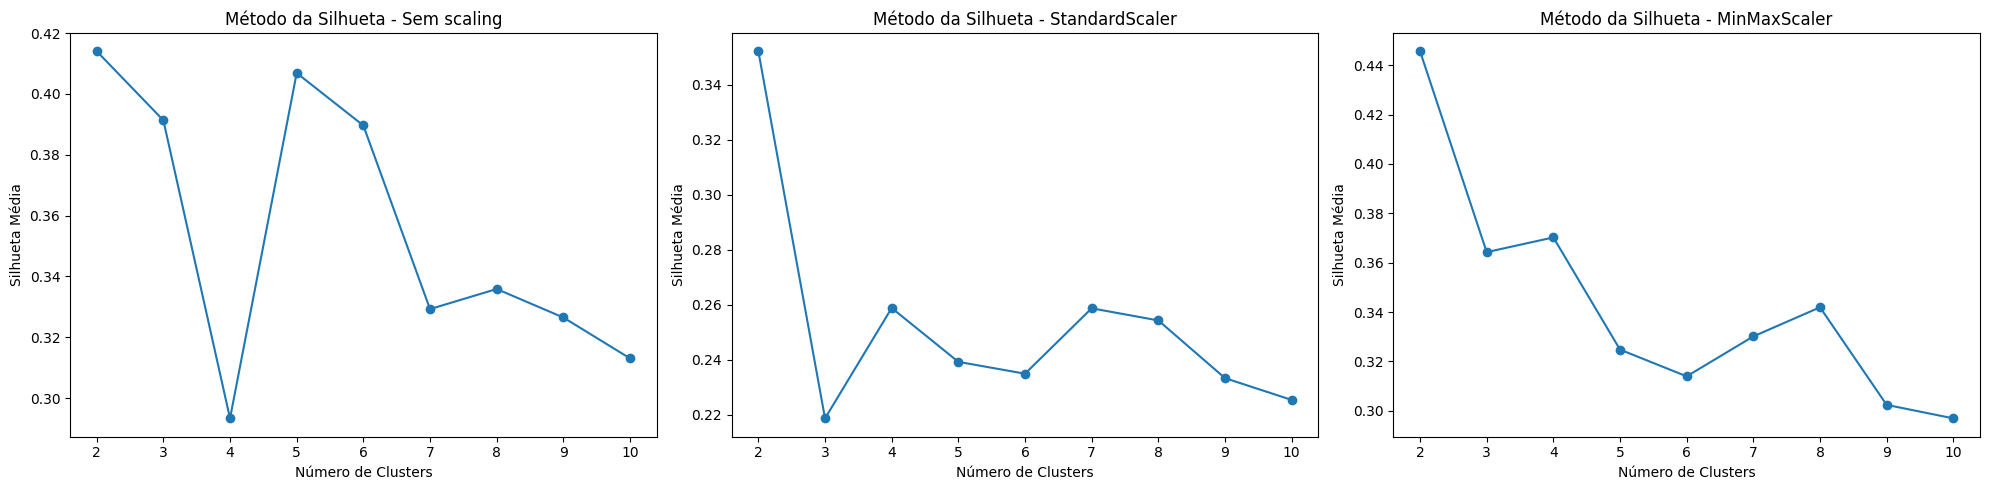

In [193]:
resultados_silueta = {}
max_clusters = 10

for nome, X in transformacoes.items():
    siluetas = []
    for n_clusters in range(2, max_clusters + 1):
        km = KMeans(n_clusters=n_clusters, random_state=42, n_init="auto").fit(X)
        siluetas.append(silhouette_score(X, km.labels_))
    resultados_silueta[nome] = siluetas

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for ax, (nome, siluetas) in zip(axes, resultados_silueta.items()):
    ax.plot(range(2, max_clusters + 1), siluetas, marker="o")
    ax.set_xlabel("Número de Clusters")
    ax.set_ylabel("Silhueta Média")
    ax.set_title(f"Método da Silhueta - {nome}")

plt.tight_layout()
plt.show()

### Métricas

In [194]:
def calcular_metricas(X, labels, nome: str = "") -> dict:
    """
    Calcula métricas intrínsecas de avaliação de clustering (não precisam
    de rótulo verdadeiro conhecido — só a estrutura geométrica).
        Parâmetros:
            X: array-like -> dados usados no clustering (qualquer nº de colunas)
            labels: array-like -> rótulos de cluster previstos
            nome: str -> identificador pra print (ex: nome da transformação/k)
        Retorna:
            dict -> métricas calculadas
    """
    print(f"Calculando métricas para: {nome}\n")

    ss = round(silhouette_score(X, labels), 3)
    print(f"Silhouette Score -> {ss}")

    chs = round(calinski_harabasz_score(X, labels), 3)
    print(f"Calinski Harabasz Score -> {chs}")

    dbs = round(davies_bouldin_score(X, labels), 3)
    print(f"Davies Bouldin Score -> {dbs}")

    return {"silhouette": ss, "calinski_harabasz": chs, "davies_bouldin": dbs}

In [195]:
resultados_metricas = []

for nome, X in transformacoes.items():
    print("========================")
    print(nome)
    for k in range(3, 7):
        
        kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")
        labels = kmeans.fit_predict(X)

        metricas = calcular_metricas(X, labels, nome=f"{nome} — k={k}")

        metricas.update({"transformacao": nome, "k": k})

        resultados_metricas.append(metricas)

Sem scaling
Calculando métricas para: Sem scaling — k=3

Silhouette Score -> 0.391
Calinski Harabasz Score -> 2776.276
Davies Bouldin Score -> 1.045
Calculando métricas para: Sem scaling — k=4

Silhouette Score -> 0.293
Calinski Harabasz Score -> 2266.323
Davies Bouldin Score -> 1.105
Calculando métricas para: Sem scaling — k=5

Silhouette Score -> 0.407
Calinski Harabasz Score -> 2652.447
Davies Bouldin Score -> 0.91
Calculando métricas para: Sem scaling — k=6

Silhouette Score -> 0.39
Calinski Harabasz Score -> 2542.619
Davies Bouldin Score -> 0.976
StandardScaler
Calculando métricas para: StandardScaler — k=3

Silhouette Score -> 0.219
Calinski Harabasz Score -> 1706.767
Davies Bouldin Score -> 1.688
Calculando métricas para: StandardScaler — k=4

Silhouette Score -> 0.259
Calinski Harabasz Score -> 1641.744
Davies Bouldin Score -> 1.459
Calculando métricas para: StandardScaler — k=5

Silhouette Score -> 0.239
Calinski Harabasz Score -> 1526.026
Davies Bouldin Score -> 1.507
Calcula

In [196]:
df_resultados = pd.DataFrame(resultados_metricas)

df_resultados

,silhouette,calinski_harabasz,davies_bouldin,transformacao,k
0,0.391,2776.276,1.045,Sem scaling,3
1,0.293,2266.323,1.105,Sem scaling,4
2,0.407,2652.447,0.910,Sem scaling,5
3,0.390,2542.619,0.976,Sem scaling,6
4,0.219,1706.767,1.688,StandardScaler,3
5,0.259,1641.744,1.459,StandardScaler,4
6,0.239,1526.026,1.507,StandardScaler,5
7,0.235,1383.442,1.560,StandardScaler,6
8,0.364,3611.313,1.149,MinMaxScaler,3
9,0.370,2949.156,1.377,MinMaxScaler,4


In [197]:
metricas = {
    "silhouette": "max",
    "calinski_harabasz": "max",
    "davies_bouldin": "min"
}

def destacar_top2(s, tipo):
    if tipo == "max":
        indices = s.nlargest(2).index
    else:
        indices = s.nsmallest(2).index

    return [
        "background-color: red" if i in indices else ""
        for i in s.index
    ]

df_resultados.style\
    .apply(
        lambda s: destacar_top2(s, metricas[s.name]),
        subset=list(metricas.keys())
    )\
    .format({
        "silhouette": "{:.3f}",
        "calinski_harabasz": "{:.3f}",
        "davies_bouldin": "{:.3f}"
    })

,silhouette,calinski_harabasz,davies_bouldin,transformacao,k
0,0.391,2776.276,1.045,Sem scaling,3
1,0.293,2266.323,1.105,Sem scaling,4
2,0.407,2652.447,0.910,Sem scaling,5
3,0.390,2542.619,0.976,Sem scaling,6
4,0.219,1706.767,1.688,StandardScaler,3
5,0.259,1641.744,1.459,StandardScaler,4
6,0.239,1526.026,1.507,StandardScaler,5
7,0.235,1383.442,1.560,StandardScaler,6
8,0.364,3611.313,1.149,MinMaxScaler,3
9,0.370,2949.156,1.377,MinMaxScaler,4


### Melhores (com base nos gráficos e métricas)
- Sem scaling 5
- MinMaxScaler 3/4

In [198]:
def ajustar_kmeans(X, k, random_state=42):
    kmeans = KMeans(n_clusters=k, random_state=random_state, n_init="auto")
    labels = kmeans.fit_predict(X)
    return labels, kmeans

In [199]:
def plotar_clusters(X, labels, df_train, metadata_alinhado, especie_plot, nome, k,
                     cor_extra=("mdr_score_plasmidial", "cat_plasmidial_beta-lactam")):
    """Só plota — recebe labels já prontos, nunca treina nada."""
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)

    n_paineis = 3 + len(cor_extra)
    fig, axes = plt.subplots(1, n_paineis, figsize=(7 * n_paineis, 5))

    sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=labels, palette="tab20", ax=axes[0])
    axes[0].set_title(f"Cluster — {nome}, k={k}")

    sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=metadata_alinhado["WHO_Priority"], palette="Set2", ax=axes[1])
    axes[1].set_title("WHO_Priority")

    sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=especie_plot, palette="tab20", ax=axes[2])
    axes[2].set_title("Species (top 8)")

    for i, coluna in enumerate(cor_extra):
        ax = axes[3 + i]
        sc = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=df_train[coluna], cmap="viridis")
        ax.set_title(f"Colorido por {coluna}")
        fig.colorbar(sc, ax=ax, label=coluna)

    for ax in axes:
        ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
        ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")

    plt.tight_layout()
    plt.show()

In [200]:
def treinar_kmeans(nome, X, k, df_train, metadata_alinhado, especie_plot,
                    plots=True, return_column=True,
                    cor_extra=("mdr_score_plasmidial", "cat_plasmidial_beta-lactam")):
    """
    Treina KMeans, opcionalmente plota, opcionalmente anota a coluna de
    cluster em df_train e imprime o crosstab/média de diagnóstico.
    """
    labels, kmeans = ajustar_kmeans(X, k)

    if plots:
        plotar_clusters(X, labels, df_train, metadata_alinhado, especie_plot, nome, k, cor_extra=cor_extra)

    if return_column:
        nome_coluna = f"k_means_{nome.lower().replace(' ', '_')}_{k}"
        df_train[nome_coluna] = labels

        print(f"\nDistribuição de WHO_Priority por cluster ({nome_coluna}):")
        display(pd.crosstab(df_train[nome_coluna], metadata_alinhado["WHO_Priority"], normalize="index"))

        print(f"\nMédia de mdr_score_plasmidial por cluster ({nome_coluna}):")
        display(df_train.groupby(nome_coluna)["mdr_score_plasmidial"].mean())

    return labels, kmeans

### Plotando

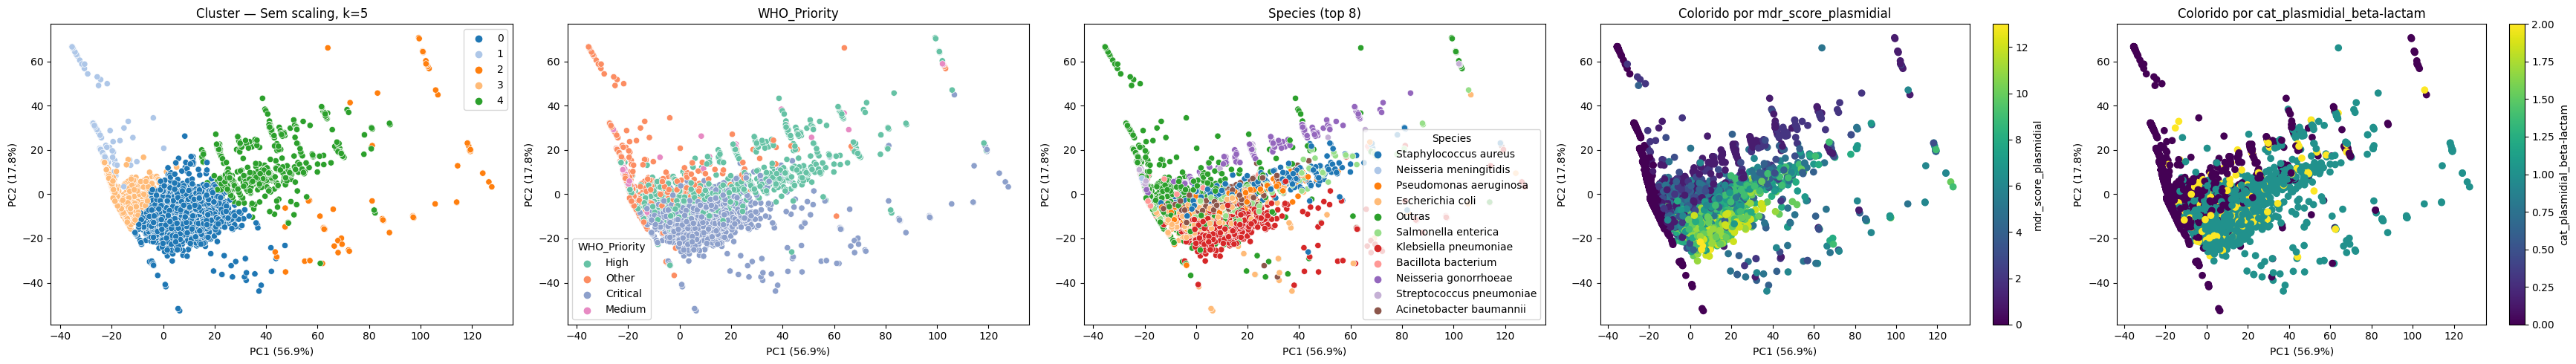


Distribuição de WHO_Priority por cluster (k_means_sem_scaling_5):


WHO_Priority,Critical,High,Medium,Other
k_means_sem_scaling_5,,,,
0,0.663417,0.289379,0.001539,0.045664
1,0.000000,0.029412,0.046218,0.924370
2,0.738636,0.181818,0.022727,0.056818
3,0.059895,0.228079,0.191663,0.520364
4,0.138298,0.803191,0.024823,0.033688



Média de mdr_score_plasmidial por cluster (k_means_sem_scaling_5):


k_means_sem_scaling_5
0    6.879425
1    0.205882
2    4.931818
3    0.366555
4    4.721631
Name: mdr_score_plasmidial, dtype: float64

In [201]:
labels, kmeans = treinar_kmeans('Sem scaling', 
                                transformacoes['Sem scaling'], 
                                k=5, 
                                df_train=df_train, 
                                metadata_alinhado=metadata_alinhado, 
                                especie_plot=especie_plot_completo)

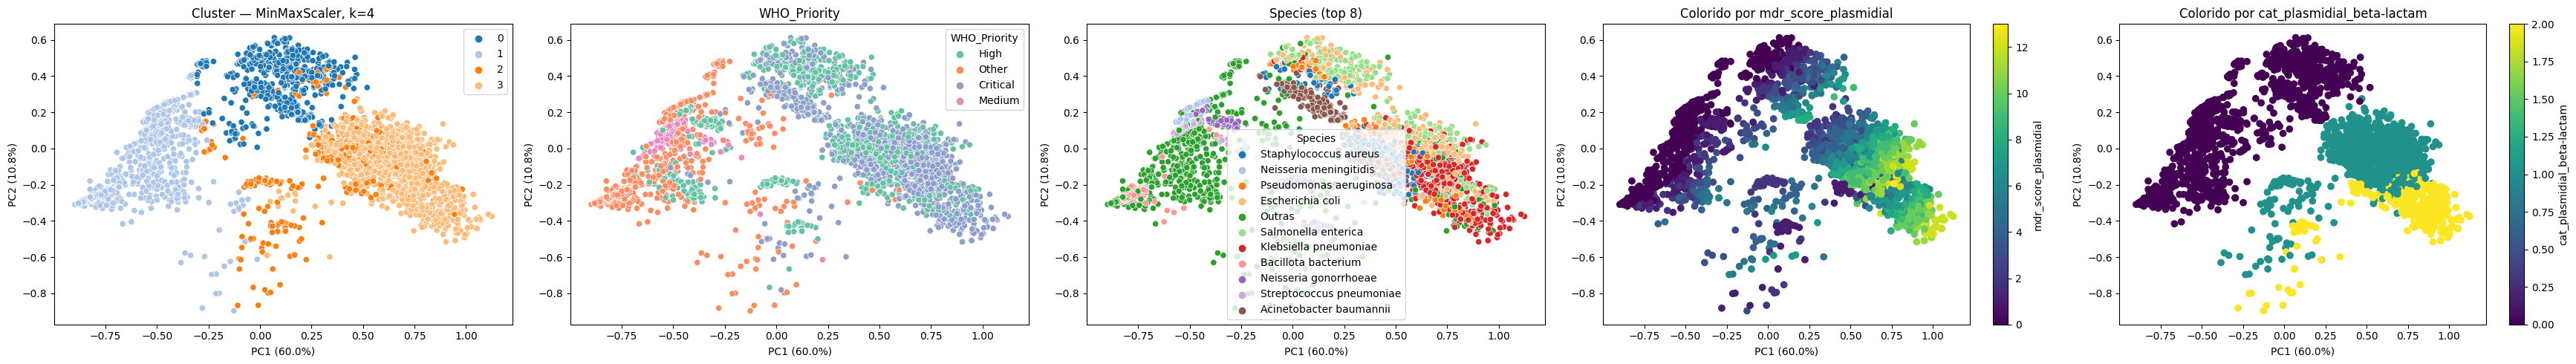


Distribuição de WHO_Priority por cluster (k_means_minmaxscaler_4):


WHO_Priority,Critical,High,Medium,Other
k_means_minmaxscaler_4,,,,
0,0.414326,0.483146,0.000000,0.102528
1,0.007052,0.177715,0.199342,0.615891
2,0.331933,0.596639,0.012605,0.058824
3,0.678461,0.316574,0.000000,0.004966



Média de mdr_score_plasmidial por cluster (k_means_minmaxscaler_4):


k_means_minmaxscaler_4
0    2.396067
1    0.294781
2    3.957983
3    8.132837
Name: mdr_score_plasmidial, dtype: float64

In [202]:
labels, kmeans = treinar_kmeans('MinMaxScaler', 
                                transformacoes['MinMaxScaler'], 
                                k=4, 
                                df_train=df_train, 
                                metadata_alinhado=metadata_alinhado, 
                                especie_plot=especie_plot_completo)

## DBSCAM

In [203]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

### Vendo o plot para achar o eps

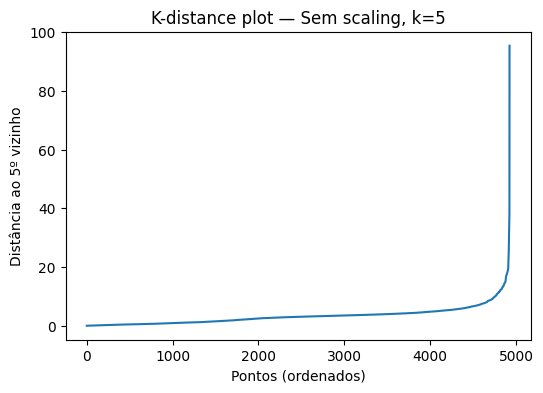

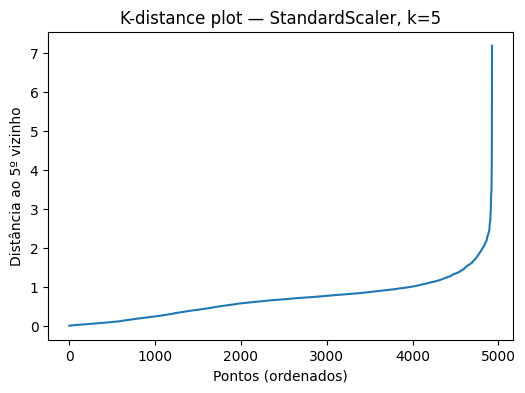

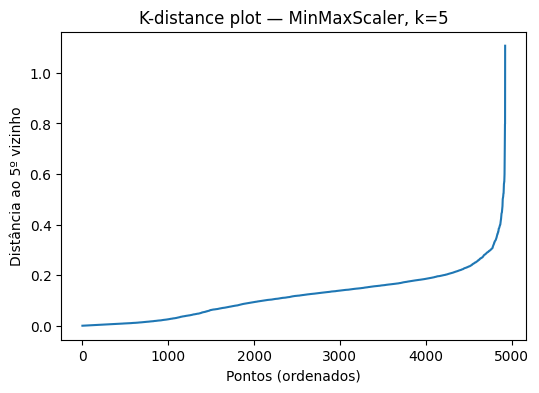

In [204]:
def plot_k_distance(X, k, nome=""):
    vizinhos = NearestNeighbors(n_neighbors=k).fit(X)
    distancias, _ = vizinhos.kneighbors(X)
    distancias_k = np.sort(distancias[:, -1])  # distância ao k-ésimo vizinho, ordenada

    plt.figure(figsize=(6, 4))
    plt.plot(distancias_k)
    plt.ylabel(f"Distância ao {k}º vizinho")
    plt.xlabel("Pontos (ordenados)")
    plt.title(f"K-distance plot — {nome}, k={k}")
    plt.show()

for nome, X in transformacoes.items():
    plot_k_distance(X, k=5, nome=nome)

In [205]:
hiperparametros_df = {
    "Sem scaling": [
        transformacoes["Sem scaling"],
        [2, 3, 4, 5, 6, 7],       # min_samples
        [5, 10, 15]               # eps
    ],

    "StandardScaler": [
        transformacoes["StandardScaler"],
        [2, 3, 4, 5, 6, 7],       # min_samples
        [1, 1.5, 2]               # eps
    ],

    "MinMaxScaler": [
        transformacoes["MinMaxScaler"],
        [2, 3, 4, 5, 6, 7],       # min_samples
        [0.18, 0.2, 0.25]         # eps
    ]
}

### Testando tudo

In [206]:
for nome, (X, min_samples_list, eps_list) in hiperparametros_df.items():
    print(nome, "==============")
    for sample in min_samples_list:
        for ep in eps_list:
            db = DBSCAN(eps=ep, min_samples=sample)
            clusters = db.fit_predict(X)
            rotulos, contagens = np.unique(clusters, return_counts=True)

            print("-----" * 20)
            print(f"{nome} | DBSCAN with eps={ep} and min_samples={sample}")
            print(rotulos, contagens)

Sem scaling ==============
----------------------------------------------------------------------------------------------------
Sem scaling | DBSCAN with eps=5 and min_samples=2
[ -1   0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16
  17  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34
  35  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52
  53  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70
  71  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88
  89  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106
 107 108 109 110 111 112 113 114 115 116 117] [ 322 3161    7   17  552   82   13   20   11  104   68    6    2   27
    2    2    6    3    2    7   17   11   55   16    2   38   13   29
   20    3    2    7   13    6    4    2    2    5    2    2    2    3
    2    6    3    2    3    2    2    4    2    6    4    9    4    2
   10    2    2    2    2    3    4    6    2    6    

### Plotando os "melhores valores"
Na minha opinião todos ficaram horriveis, mas estou buscando aquele com um numero não tão grande de clusters, e com distruibuição boa em pelo menos 4. Em alguns casos formou poucos clusters mas mais de 4000 em um único, considerei ruim.

In [207]:
for nome, X in transformacoes.items():
    print(nome)

Sem scaling
StandardScaler
MinMaxScaler


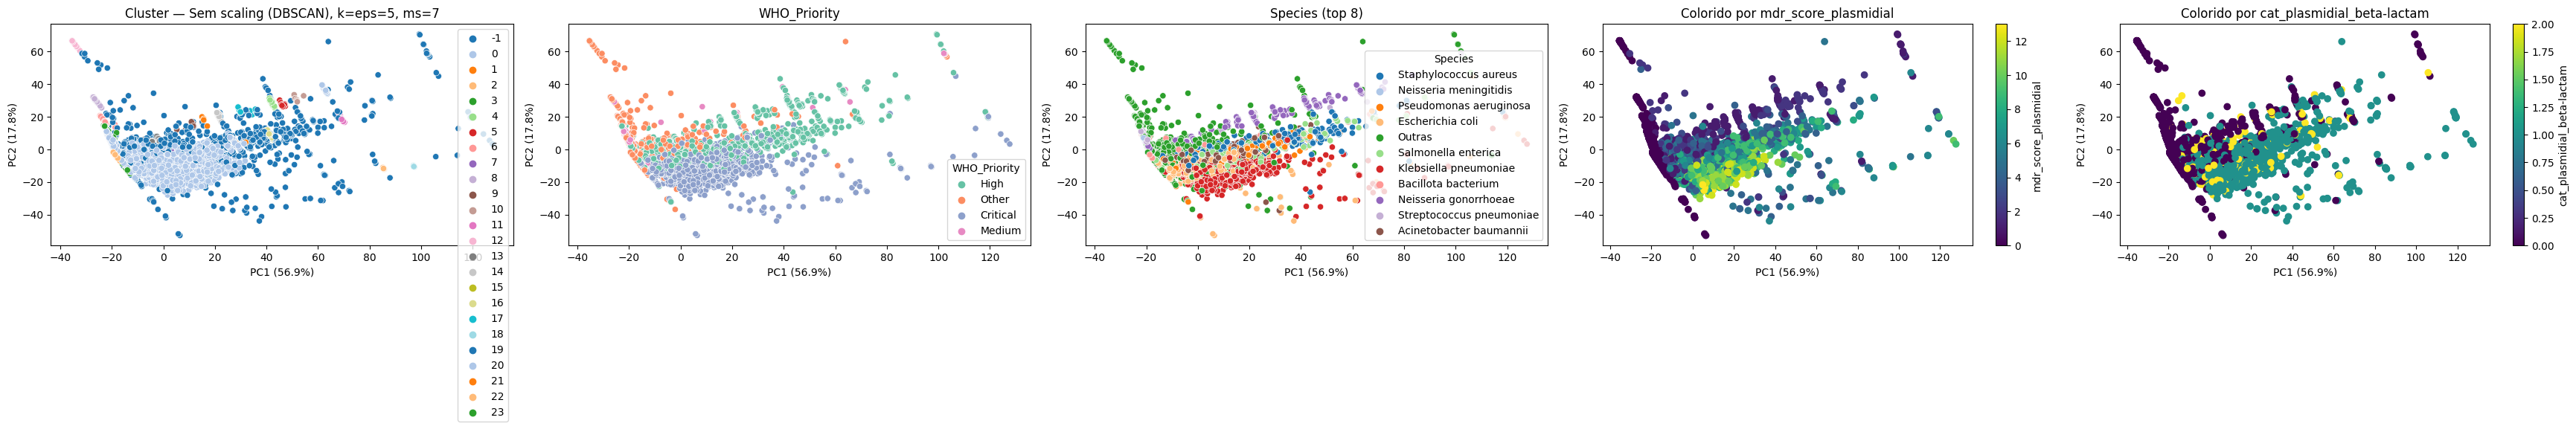

In [208]:
# Sem Scaling
db1 = DBSCAN(eps=5, min_samples=7)
labels_db1 = db1.fit_predict(transformacoes['Sem scaling'])

plotar_clusters(transformacoes['Sem scaling'], 
                labels_db1, 
                df_train, 
                metadata_alinhado, 
                especie_plot_completo, 
                nome="Sem scaling (DBSCAN)", 
                k="eps=5, ms=7")

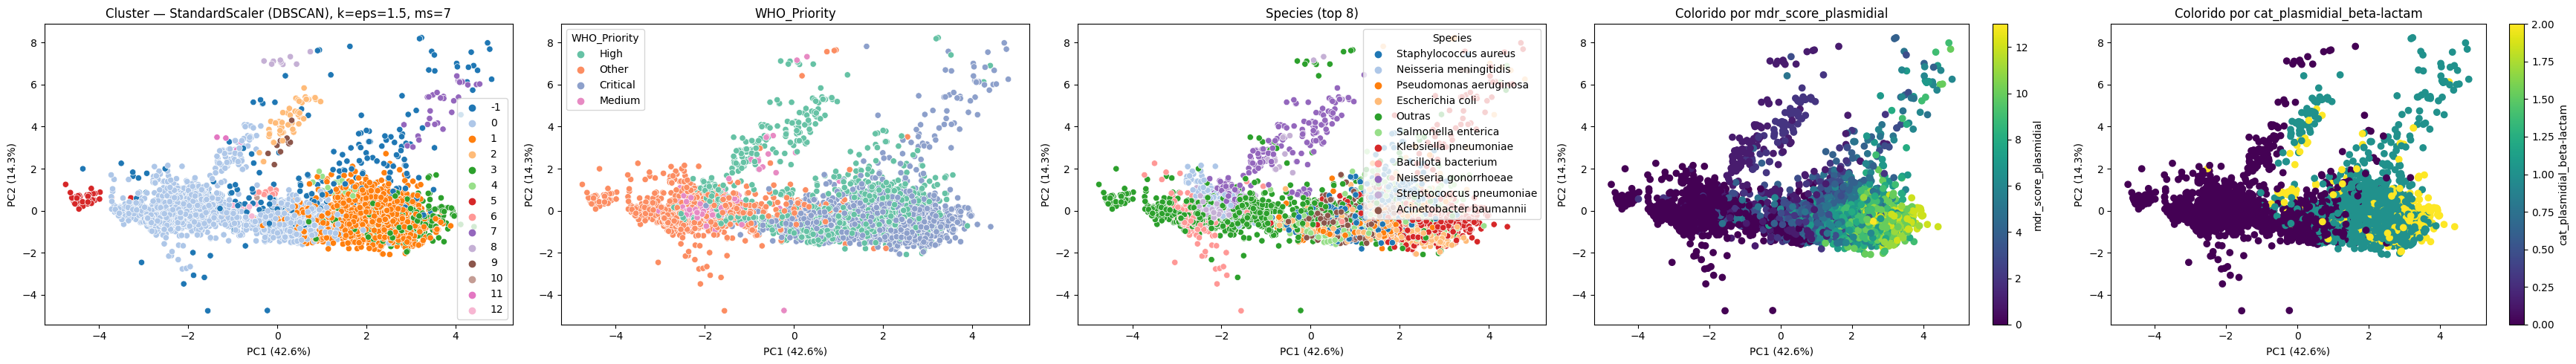

In [209]:
# StandardScaler
db2 = DBSCAN(eps=1.5, min_samples=7)
labels_db2 = db2.fit_predict(transformacoes['StandardScaler'])

plotar_clusters(transformacoes['StandardScaler'], 
                labels_db2, 
                df_train, 
                metadata_alinhado, 
                especie_plot_completo, 
                nome="StandardScaler (DBSCAN)", 
                k="eps=1.5, ms=7")

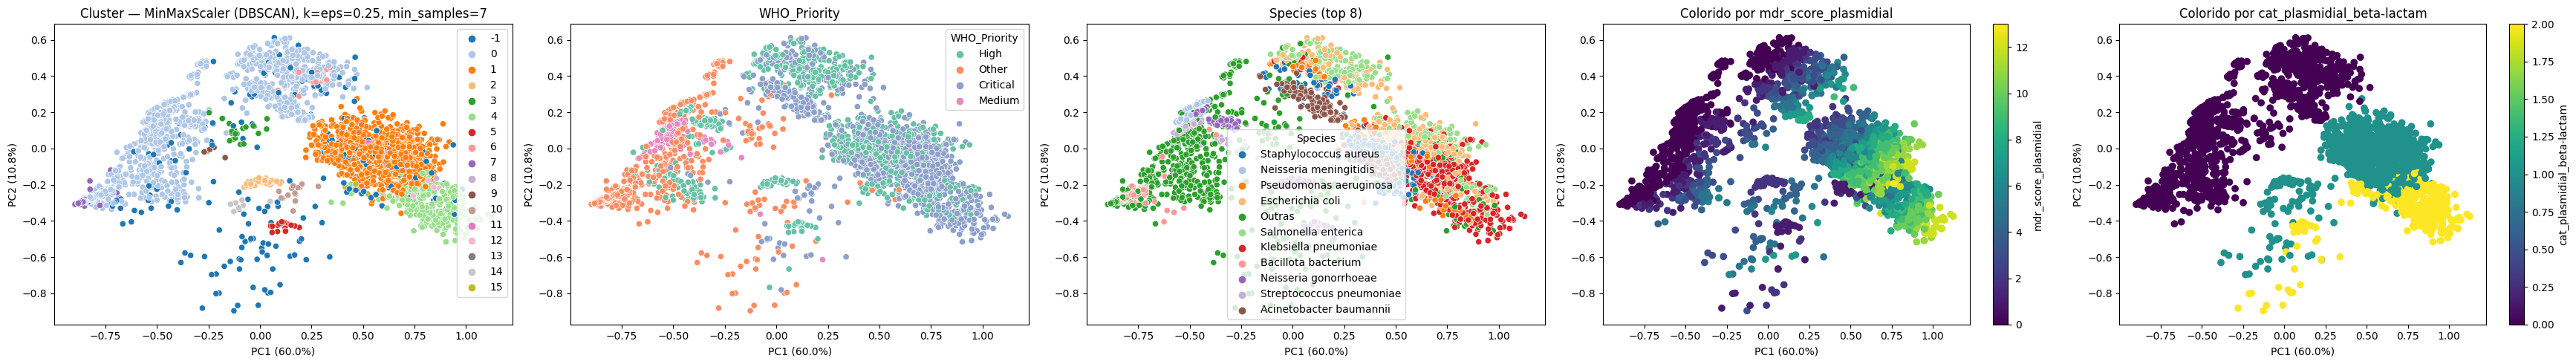

In [210]:
# MinMaxScaler
db3 = DBSCAN(eps=0.25, min_samples=7)
labels_db3 = db3.fit_predict(transformacoes['MinMaxScaler'])

plotar_clusters(transformacoes['MinMaxScaler'], 
                labels_db3, 
                df_train, 
                metadata_alinhado, 
                especie_plot_completo, 
                nome="MinMaxScaler (DBSCAN)", 
                k="eps=0.25, min_samples=7")

### Calculando métricas

In [211]:
calcular_metricas(transformacoes['Sem scaling'], 
                  labels_db1, 
                  nome="Sem scaling - eps=5, ms=7")

Calculando métricas para: Sem scaling - eps=5, ms=7



Silhouette Score -> -0.189
Calinski Harabasz Score -> 185.804
Davies Bouldin Score -> 1.278


{'silhouette': -0.189, 'calinski_harabasz': 185.804, 'davies_bouldin': 1.278}

In [212]:
calcular_metricas(transformacoes['StandardScaler'], 
                  labels_db2, 
                  nome="StandardScaler - eps=1.5, ms=7")

Calculando métricas para: StandardScaler - eps=1.5, ms=7

Silhouette Score -> 0.028
Calinski Harabasz Score -> 330.145
Davies Bouldin Score -> 1.551


{'silhouette': 0.028, 'calinski_harabasz': 330.145, 'davies_bouldin': 1.551}

In [213]:
calcular_metricas(transformacoes['MinMaxScaler'], 
                  labels_db3, 
                  nome="MinMax - eps=0.25, ms=7")

Calculando métricas para: MinMax - eps=0.25, ms=7

Silhouette Score -> 0.115
Calinski Harabasz Score -> 406.667
Davies Bouldin Score -> 1.43


{'silhouette': 0.115, 'calinski_harabasz': 406.667, 'davies_bouldin': 1.43}

## Agrupamento Hierárquico

In [214]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.neighbors import kneighbors_graph
from scipy.cluster.hierarchy import dendrogram, linkage

In [215]:
def plotar_dendrograma(X, nome=""):
    linked = linkage(X, method="ward")
    plt.figure(figsize=(10, 5))
    dendrogram(linked, orientation="top", distance_sort="descending", show_leaf_counts=True, no_labels=True)
    plt.title(f"Dendrograma — {nome}")
    plt.xlabel("Pontos de dados")
    plt.ylabel("Distância Euclidiana (Ward)")
    plt.show()
    return linked

In [216]:
# Definido depois de ver o dendograma 'cru'

alturas_corte = {
    "Sem scaling": 750,  # depois testar 580    
    "StandardScaler": 70,   
    "MinMaxScaler": 12,      
}

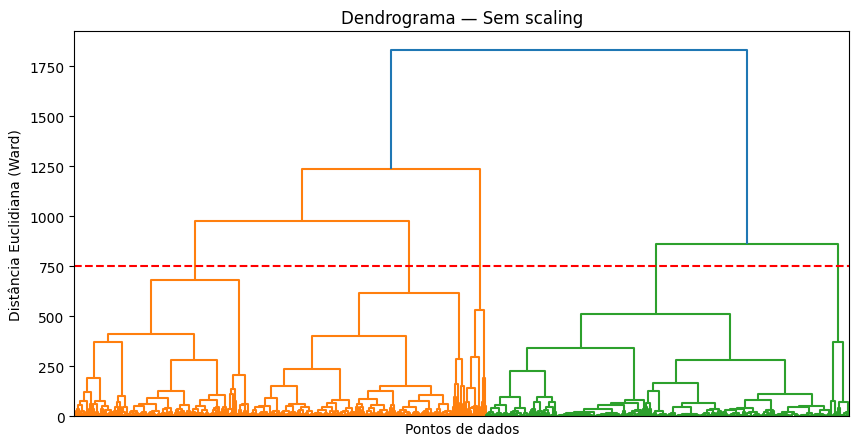

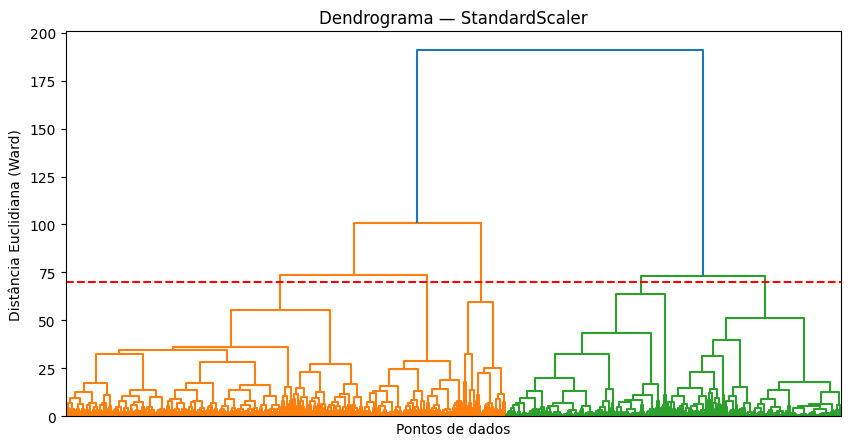

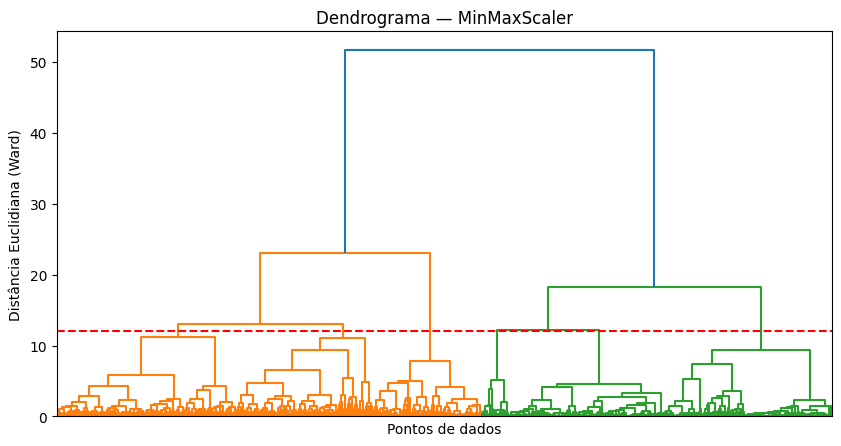

In [217]:
def plotar_dendrograma(X, nome=""):

    distancia = alturas_corte[nome]

    linked = linkage(X, method="ward")
    plt.figure(figsize=(10, 5))
    dendrogram(linked, orientation="top", distance_sort="descending", show_leaf_counts=True, no_labels=True)
    plt.title(f"Dendrograma — {nome}")
    plt.xlabel("Pontos de dados")
    plt.ylabel("Distância Euclidiana (Ward)")
    plt.axhline(y=distancia, color="r", linestyle="--")  # Linha de corte imaginária para definir 3 clusters
    plt.show()
    return linked   

linkages = {}
for nome, X in transformacoes.items():
    linkages[nome] = plotar_dendrograma(X, nome=nome)

In [218]:
# 4. Aplicar o algoritmo com o número de clusters desejado

def ajustar_agglomerative(X, nome, distancia):

    if nome ==  "Sem scaling":
        n_neighbors = 5
    elif nome == "StandardScaler":
        n_neighbors = 5
    elif nome == "MinMaxScaler":
        n_neighbors = 6
    
    matriz_conectividade = kneighbors_graph(X, n_neighbors=n_neighbors, include_self=False)
    modelo = AgglomerativeClustering(
        n_clusters=None,                    # Desativado para usar distance_threshold
        distance_threshold=distancia,       # Corte do dendrograma na altura 70
        metric="euclidean",                 # Métrica de distância em linha reta
        linkage="ward",                     # Minimiza a variância total dentro de cada cluster
        connectivity=matriz_conectividade,  # Apensar funde pontos se forem vizinhos
    )

    labels = modelo.fit_predict(X)
    return labels, modelo

In [219]:
resultados_agg = {}
for nome, distancia in alturas_corte.items():
    X = transformacoes[nome]
    labels, modelo = ajustar_agglomerative(X, nome, distancia)
    resultados_agg[nome] = labels
    print(f"{nome}: {len(set(labels))} clusters")

/usr/local/lib/python3.10/site-packages/sklearn/cluster/_agglomerative.py:321: UserWarning: the number of connected components of the connectivity matrix is 11 > 1. Completing it to avoid stopping the tree early.
  connectivity, n_connected_components = _fix_connectivity(


Sem scaling: 5 clusters


/usr/local/lib/python3.10/site-packages/sklearn/cluster/_agglomerative.py:321: UserWarning: the number of connected components of the connectivity matrix is 4 > 1. Completing it to avoid stopping the tree early.
  connectivity, n_connected_components = _fix_connectivity(


StandardScaler: 5 clusters


/usr/local/lib/python3.10/site-packages/sklearn/cluster/_agglomerative.py:321: UserWarning: the number of connected components of the connectivity matrix is 5 > 1. Completing it to avoid stopping the tree early.
  connectivity, n_connected_components = _fix_connectivity(


MinMaxScaler: 6 clusters


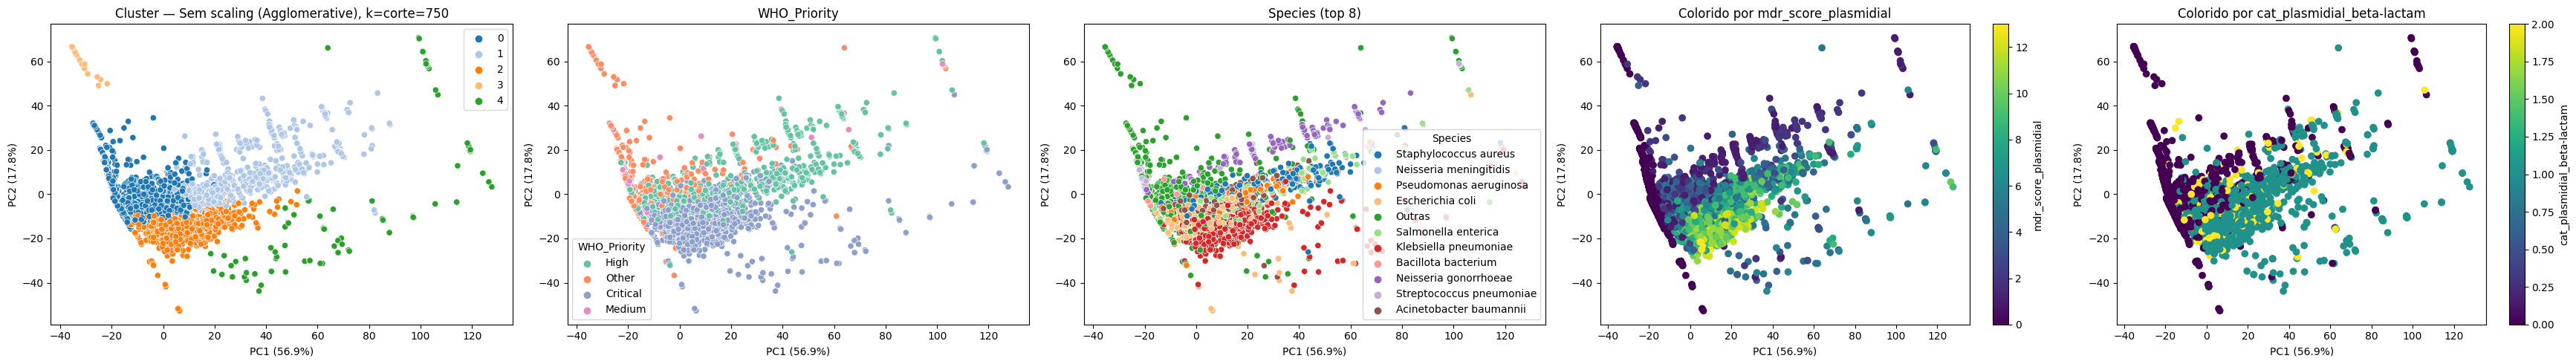

Calculando métricas para: Sem scaling (Agglomerative)

Silhouette Score -> 0.325
Calinski Harabasz Score -> 1948.918
Davies Bouldin Score -> 0.871


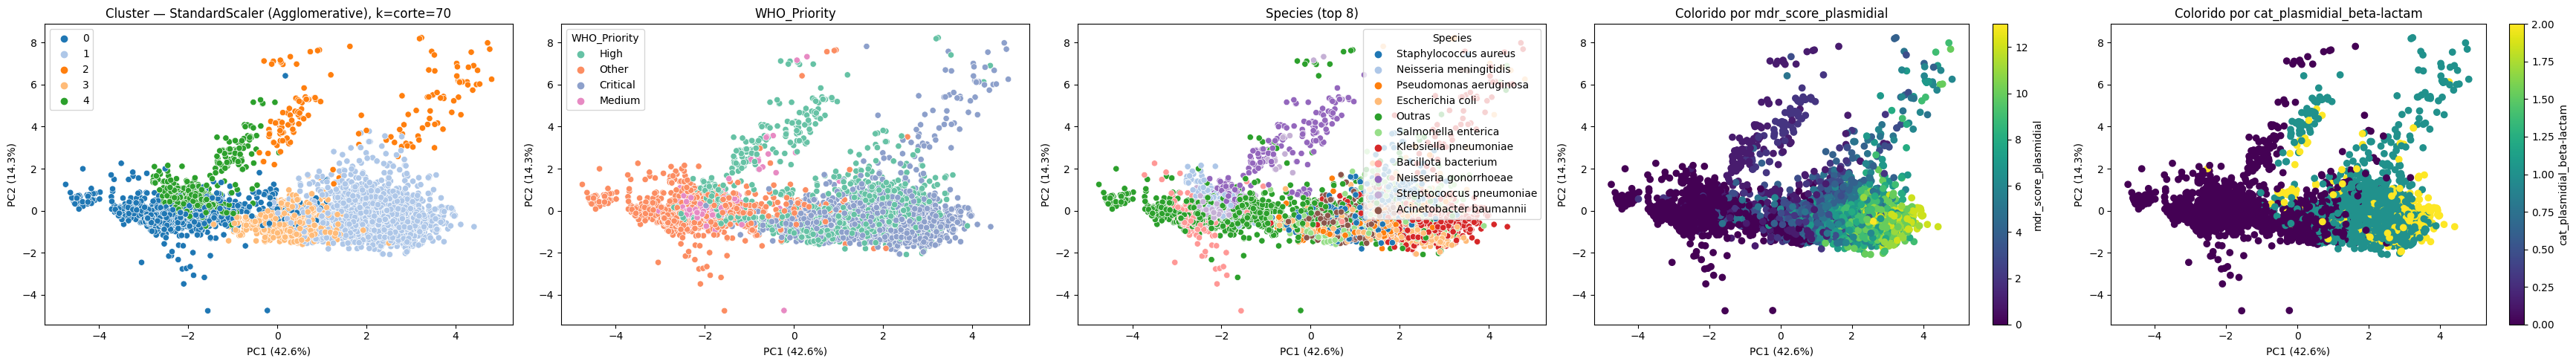

Calculando métricas para: StandardScaler (Agglomerative)

Silhouette Score -> 0.208
Calinski Harabasz Score -> 1379.267
Davies Bouldin Score -> 1.479


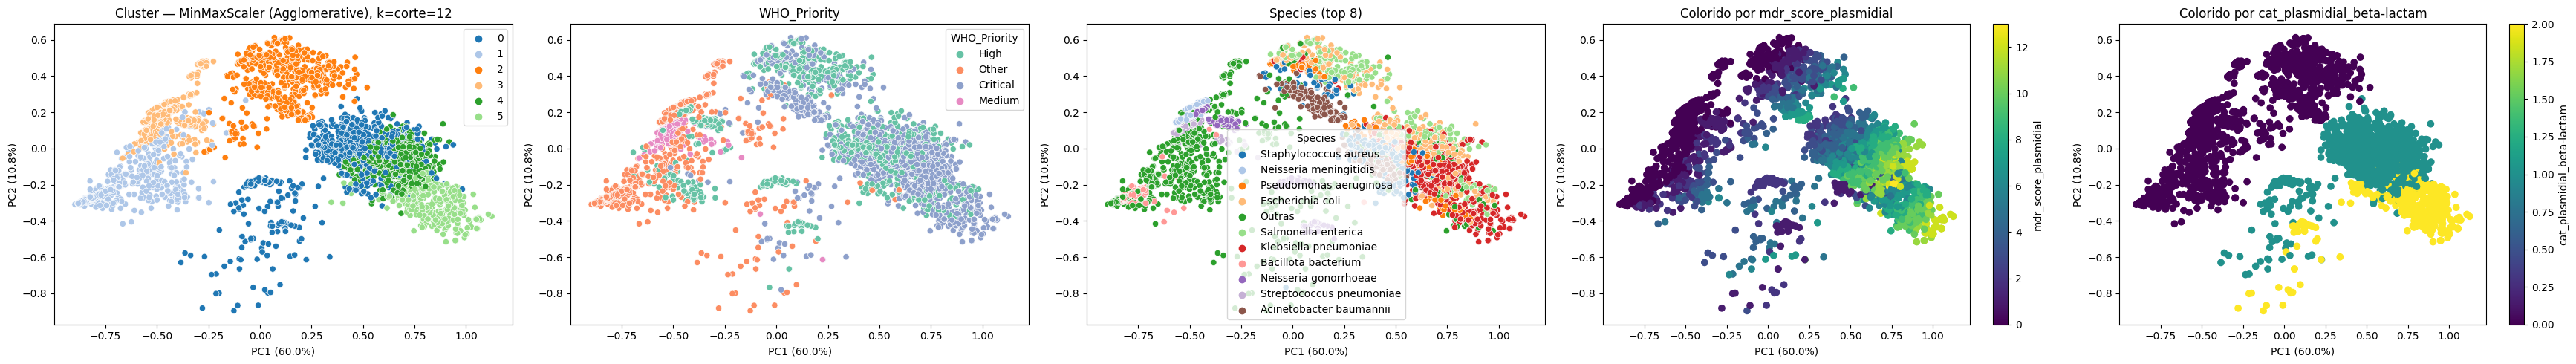

Calculando métricas para: MinMaxScaler (Agglomerative)

Silhouette Score -> 0.297
Calinski Harabasz Score -> 2391.618
Davies Bouldin Score -> 1.411


In [220]:
for nome, labels in resultados_agg.items():
    X = transformacoes[nome]
    plotar_clusters(X, labels, df_train, metadata_alinhado, especie_plot_completo, nome=f"{nome} (Agglomerative)", k=f"corte={alturas_corte[nome]}")
    calcular_metricas(X, labels, nome=f"{nome} (Agglomerative)")

## Adicionando os cluster em df_train

In [221]:
df_train["dbscan_minmax_eps025_ms7"] = labels_db3
df_train["agg_sem_scaling"] = resultados_agg["Sem scaling"]
df_train["agg_minmax"] = resultados_agg["MinMaxScaler"]

In [222]:
colunas_cluster = [c for c in df_train.columns if c.startswith(("k_means", "dbscan", "agg"))]
print(colunas_cluster)

['k_means_sem_scaling_5', 'k_means_minmaxscaler_4', 'dbscan_minmax_eps025_ms7', 'agg_sem_scaling', 'agg_minmax']


In [223]:
df_train[colunas_cluster].head()

,k_means_sem_scaling_5,k_means_minmaxscaler_4,dbscan_minmax_eps025_ms7,agg_sem_scaling,agg_minmax
sample,,,,,
GCA_021009385.1,0,0,0,1,2
GCA_015825355.1,3,1,0,0,3
GCA_038594105.1,0,3,1,0,4
GCA_019201995.1,0,0,0,2,2
GCA_038066875.1,3,1,0,0,1


### Comparando diferentes clusters com ARI e AMI

In [224]:
from sklearn.metrics import adjusted_rand_score, adjusted_mutual_info_score
import itertools

In [226]:
for col_a, col_b in itertools.combinations(colunas_cluster, 2):
    print(col_a, col_b)

k_means_sem_scaling_5 k_means_minmaxscaler_4
k_means_sem_scaling_5 dbscan_minmax_eps025_ms7
k_means_sem_scaling_5 agg_sem_scaling
k_means_sem_scaling_5 agg_minmax
k_means_minmaxscaler_4 dbscan_minmax_eps025_ms7
k_means_minmaxscaler_4 agg_sem_scaling
k_means_minmaxscaler_4 agg_minmax
dbscan_minmax_eps025_ms7 agg_sem_scaling
dbscan_minmax_eps025_ms7 agg_minmax
agg_sem_scaling agg_minmax


In [ ]:
resultados_comparacao = []

# Como não tem um target oficial, aqui estão sendo testados 1 contra o outro
for col_a, col_b in itertools.combinations(colunas_cluster, 2):
    ari = round(adjusted_rand_score(df_train[col_a], df_train[col_b]), 3)
    ami = round(adjusted_mutual_info_score(df_train[col_a], df_train[col_b]), 3)
    resultados_comparacao.append({"metodo_a": col_a, "metodo_b": col_b, "ARI": ari, "AMI": ami})

df_comparacao = pd.DataFrame(resultados_comparacao).sort_values("ARI", ascending=False)
df_comparacao

,metodo_a,metodo_b,ARI,AMI
4,k_means_minmaxscaler_4,dbscan_minmax_eps025_ms7,0.577,0.587
6,k_means_minmaxscaler_4,agg_minmax,0.501,0.656
0,k_means_sem_scaling_5,k_means_minmaxscaler_4,0.475,0.429
2,k_means_sem_scaling_5,agg_sem_scaling,0.442,0.516
7,dbscan_minmax_eps025_ms7,agg_sem_scaling,0.430,0.331
1,k_means_sem_scaling_5,dbscan_minmax_eps025_ms7,0.401,0.365
8,dbscan_minmax_eps025_ms7,agg_minmax,0.378,0.588
5,k_means_minmaxscaler_4,agg_sem_scaling,0.366,0.331
3,k_means_sem_scaling_5,agg_minmax,0.261,0.351
9,agg_sem_scaling,agg_minmax,0.217,0.294


### Fazendo funções diagnóstico

In [235]:
def plot_heatmap_categorica(cluster_col, comparacao_col, df_train, metadata_alinhado, nome_cluster):
    """Crosstab normalizado (proporção por cluster) + heatmap, pra colunas categóricas."""
    crosstab = pd.crosstab(
        df_train[cluster_col], comparacao_col, normalize="index")
    
    plt.figure(figsize=(max(6, crosstab.shape[1] * 0.8), max(4, crosstab.shape[0] * 0.5)))
    sns.heatmap(crosstab, annot=True, fmt=".2f", cmap="viridis")
    plt.title(f"{nome_cluster} × {comparacao_col.name}")
    plt.ylabel(nome_cluster)
    plt.tight_layout()
    plt.show()

In [236]:
def plot_boxplots_numericas(cluster_col, df_train, colunas_numericas, nome_cluster, n_cols=4):
    """Boxplot de cada coluna numérica, separado por grupo de cluster."""
    n_linhas = -(-len(colunas_numericas) // n_cols)  # arredonda pra cima
    fig, axes = plt.subplots(n_linhas, n_cols, figsize=(n_cols * 4, n_linhas * 3.5))
    axes = axes.flatten()

    for ax, col in zip(axes, colunas_numericas):
        sns.boxplot(x=df_train[cluster_col], y=df_train[col], ax=ax)
        ax.set_title(col, fontsize=9)
        ax.set_xlabel("")

    for ax in axes[len(colunas_numericas):]:  # apaga eixos sobrando
        ax.axis("off")

    fig.suptitle(f"{nome_cluster} — distribuição das features por grupo")
    plt.tight_layout()
    plt.show()

In [239]:
colunas_numericas = [c for c in colunas_X if c != "cat_plasmidial_beta-lactam"]
print(colunas_numericas)

['pct_genes_cromossomal_efflux', 'mdr_score_cromossomal', 'mdr_score_plasmidial', 'pct_contigs_plasmidial', 'pct_plasmidial_amr', 'pct_plasmidial_conjugacao_amr', 'n_proviruses_por_mb', 'gc_diff_plasmid_cromossomo', 'virulence_score_cromossomal', 'virulence_score_plasmidial']


In [245]:
def plot_barra_empilhada(cluster_col, coluna_ordinal, df_train, nome_cluster):
    prop = pd.crosstab(df_train[cluster_col], df_train[coluna_ordinal], normalize="index")
    prop.plot(kind="bar", stacked=True, figsize=(7, 4), colormap="viridis")
    plt.title(f"{nome_cluster} — composição de {coluna_ordinal}")
    plt.ylabel("Proporção")
    plt.legend(title=coluna_ordinal, bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

In [253]:
def diagnosticar_cluster(cluster_col, df_train, metadata_alinhado, especie_plot, colunas_numericas, colunas_ordinais=()):
    nome_cluster = cluster_col

    print(f"\n{'='*60}\n{nome_cluster}\n{'='*60}")
    print(df_train[cluster_col].value_counts().sort_index())

    plot_heatmap_categorica(cluster_col, metadata_alinhado["WHO_Priority"], df_train, metadata_alinhado, nome_cluster)
    plot_heatmap_categorica(cluster_col, especie_plot, df_train, metadata_alinhado, nome_cluster)

    for col_ord in colunas_ordinais:
        plot_barra_empilhada(cluster_col, col_ord, df_train, nome_cluster)

    plot_boxplots_numericas(cluster_col, df_train, colunas_numericas, nome_cluster)

### Testando contra colunas "target"


k_means_sem_scaling_5
0    1949
1     238
2      88
3    2087
4     564
Name: k_means_sem_scaling_5, dtype: int64


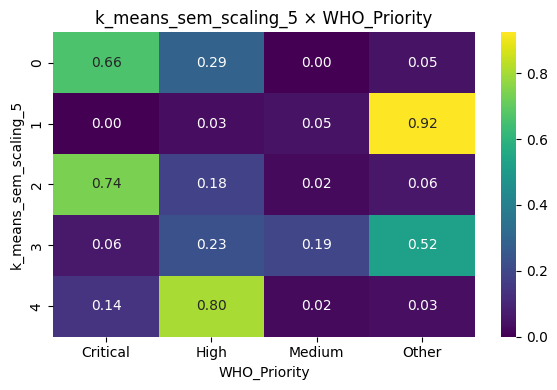

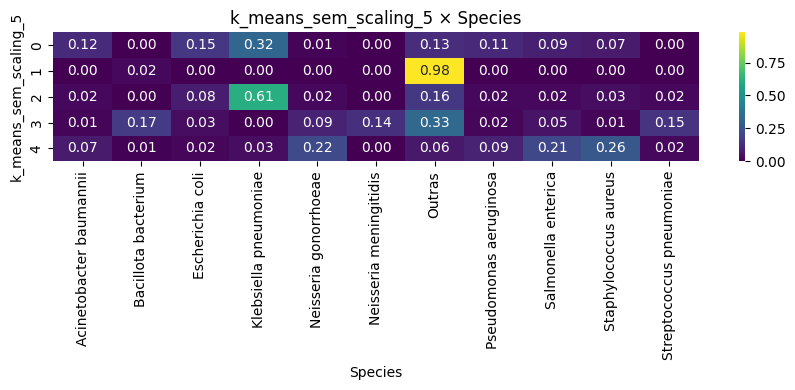

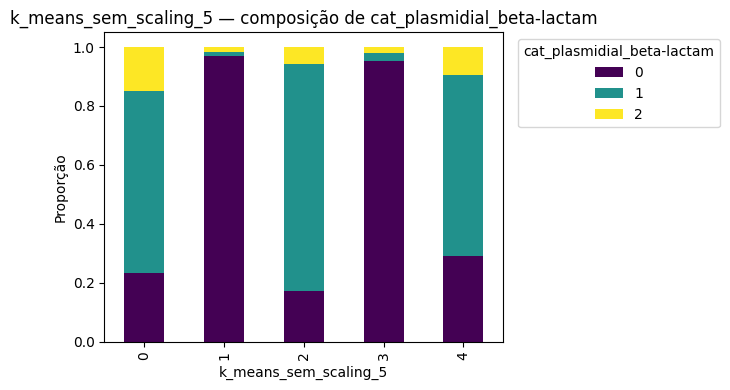

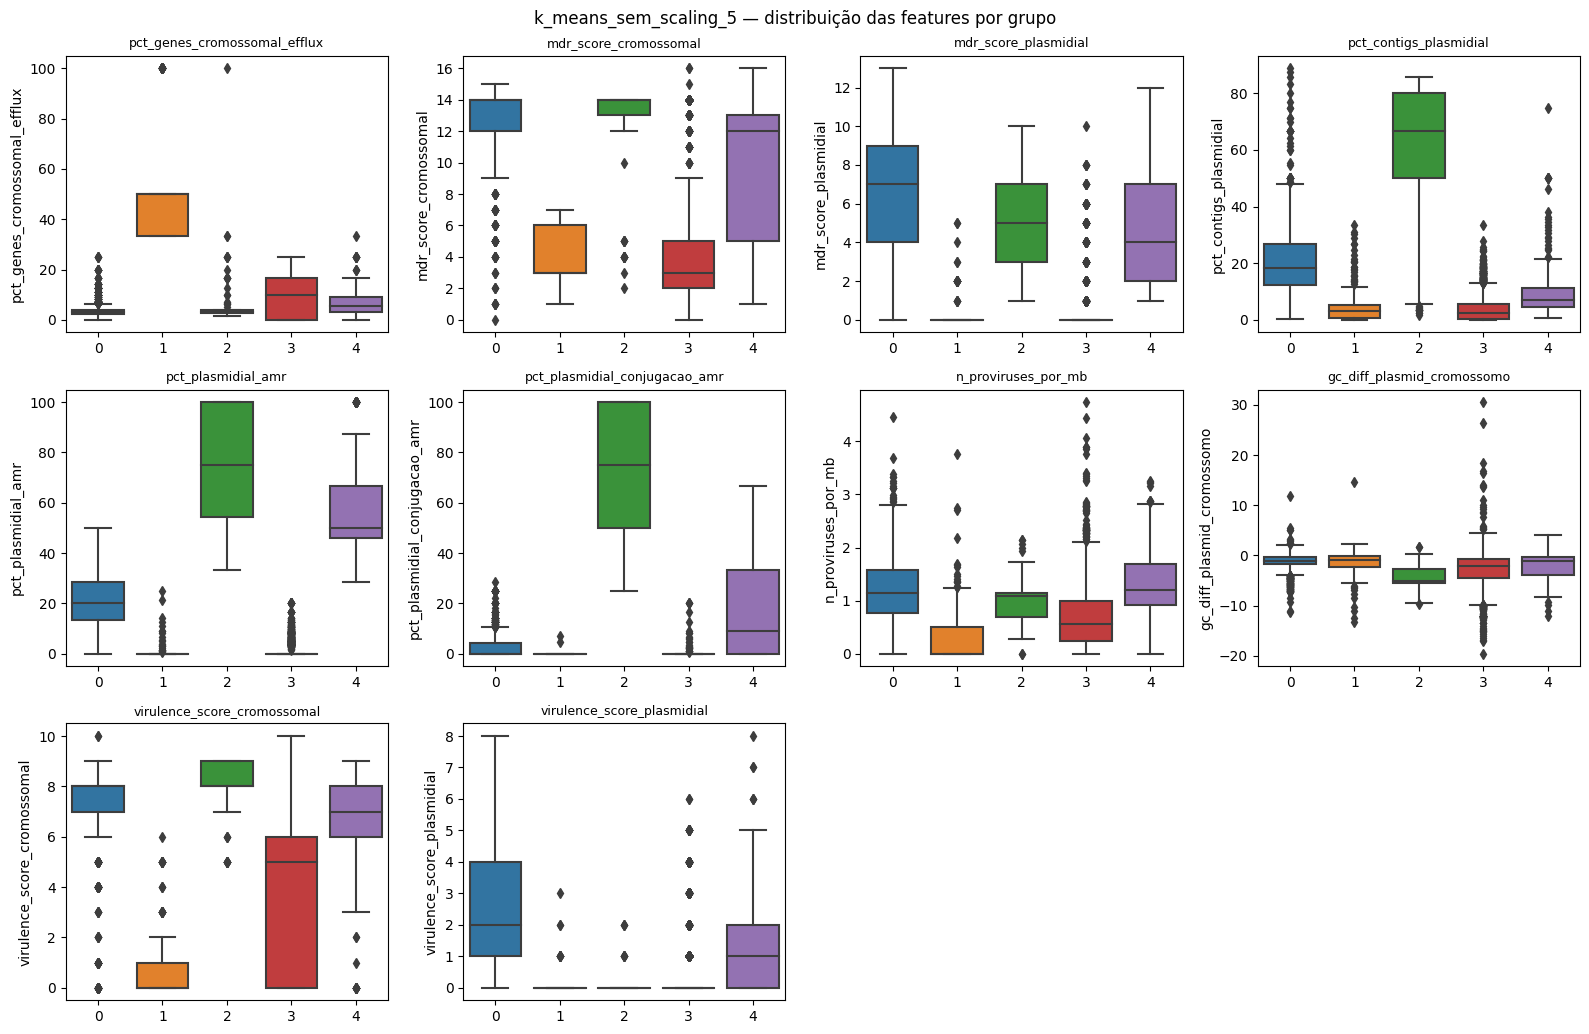


k_means_minmaxscaler_4
0     712
1    2127
2     476
3    1611
Name: k_means_minmaxscaler_4, dtype: int64


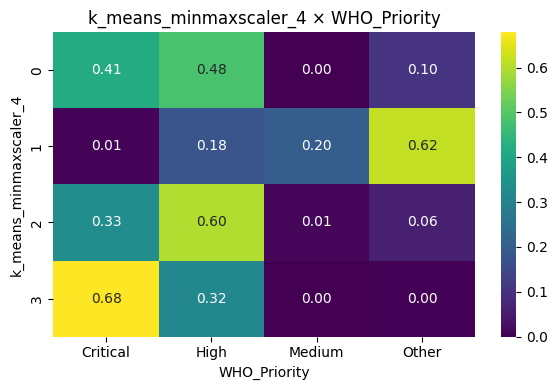

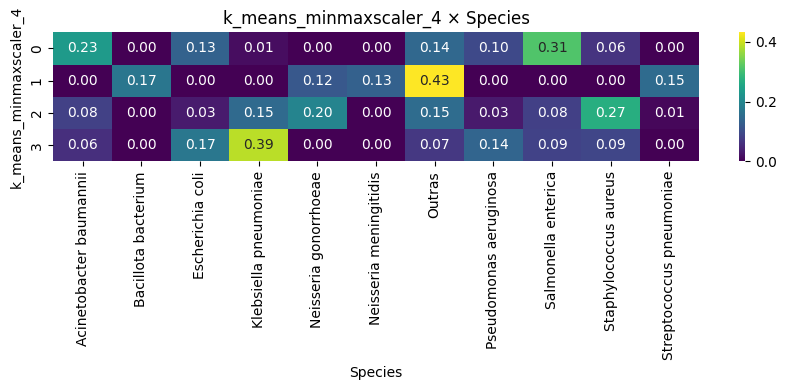

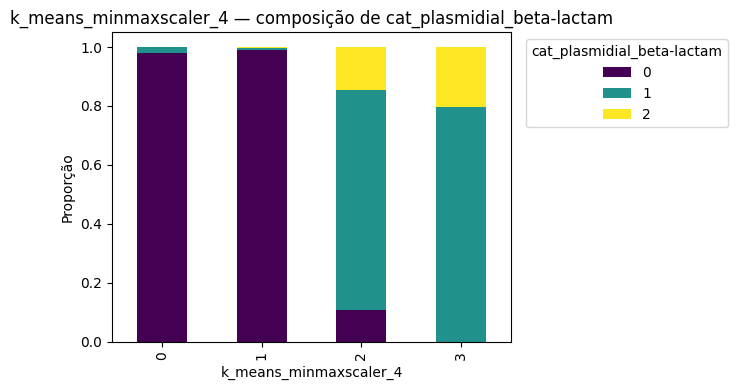

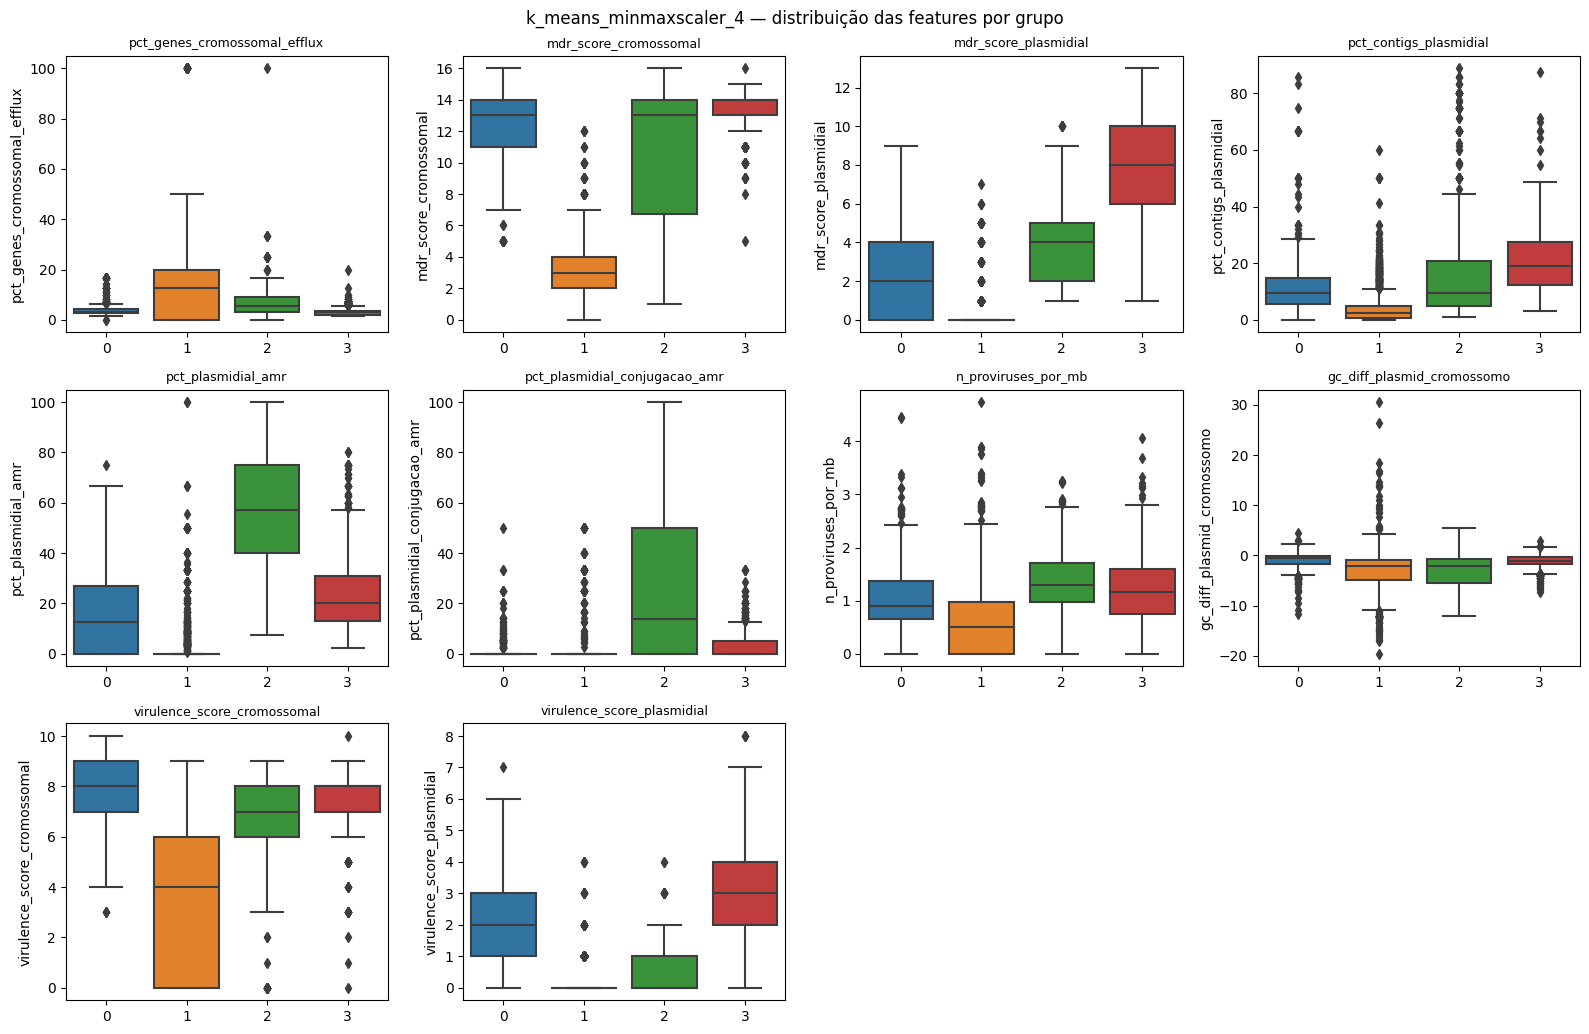


dbscan_minmax_eps025_ms7
-1      252
 0     2681
 1     1433
 2       58
 3       26
 4      304
 5       25
 6       16
 7       39
 8       24
 9        9
 10      18
 11      11
 12       7
 13       8
 14       7
 15       8
Name: dbscan_minmax_eps025_ms7, dtype: int64


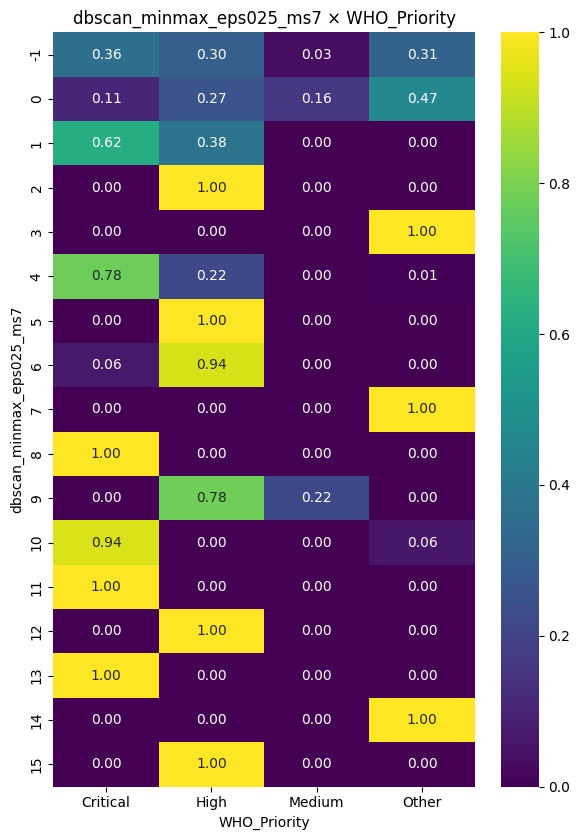

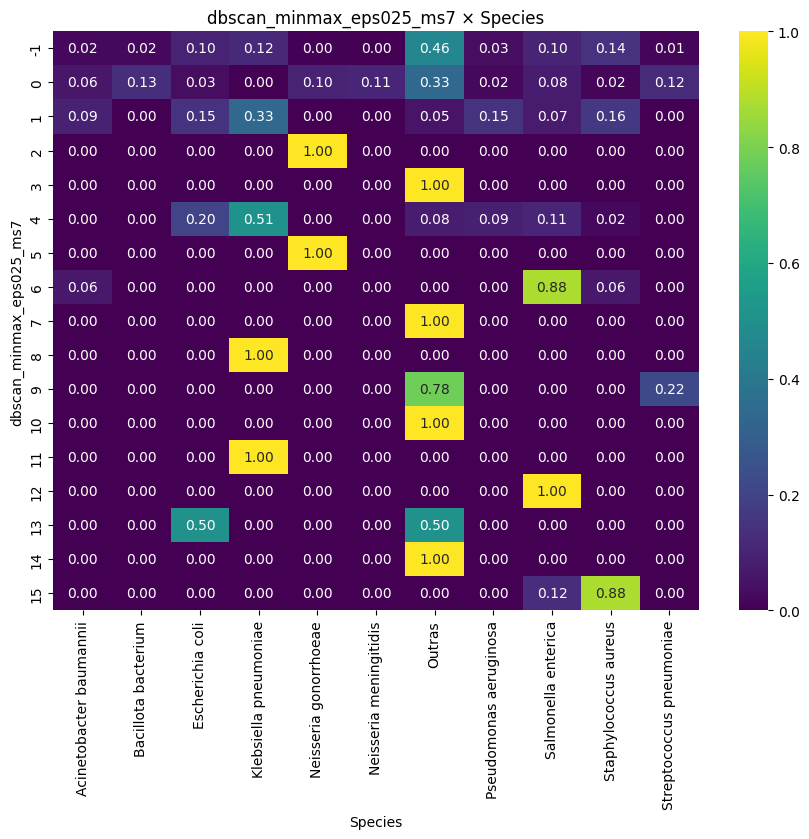

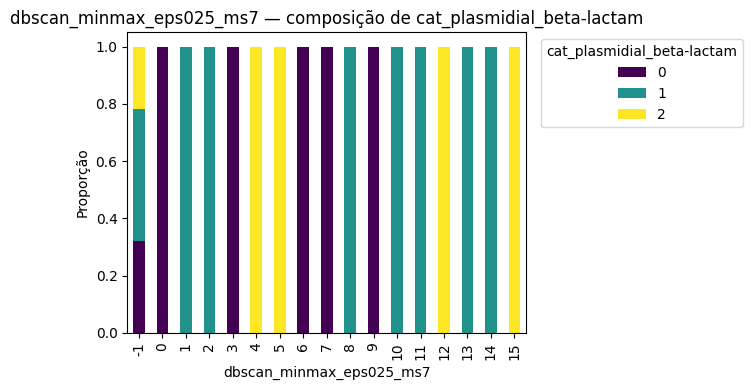

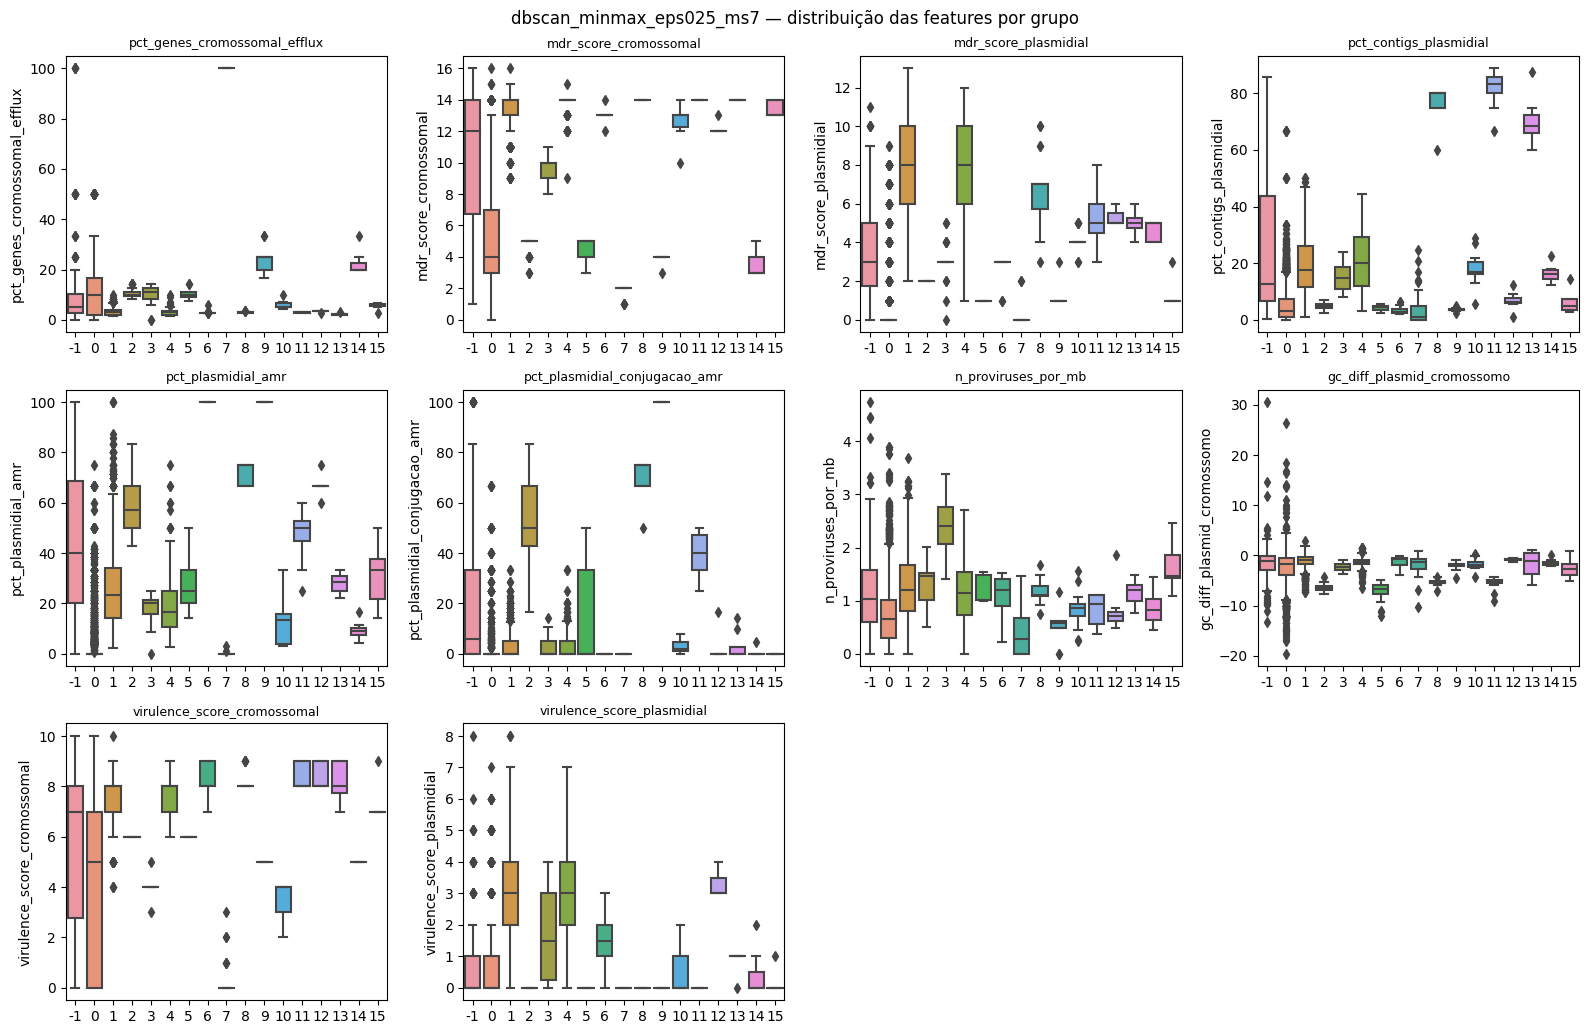


agg_sem_scaling
0    2837
1     952
2     986
3      42
4     109
Name: agg_sem_scaling, dtype: int64


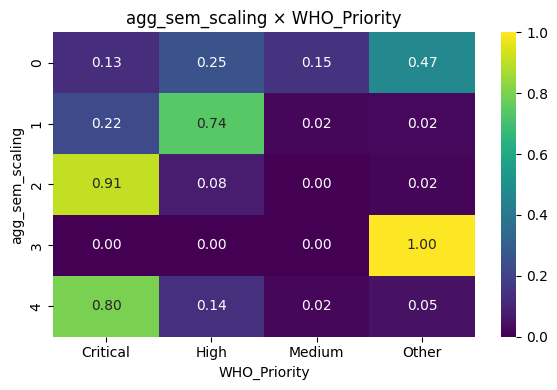

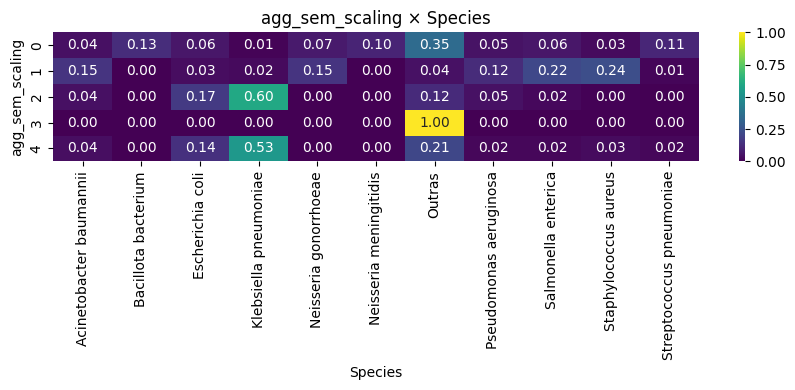

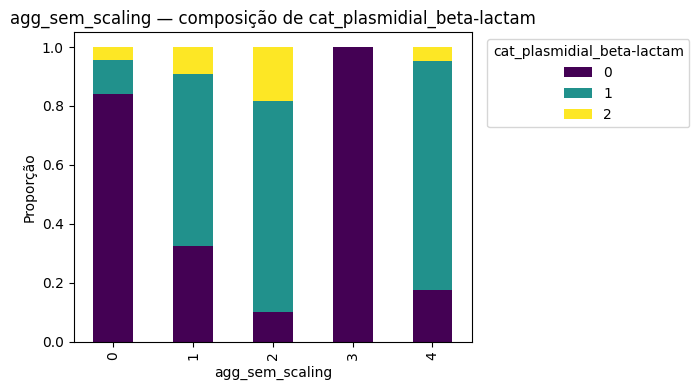

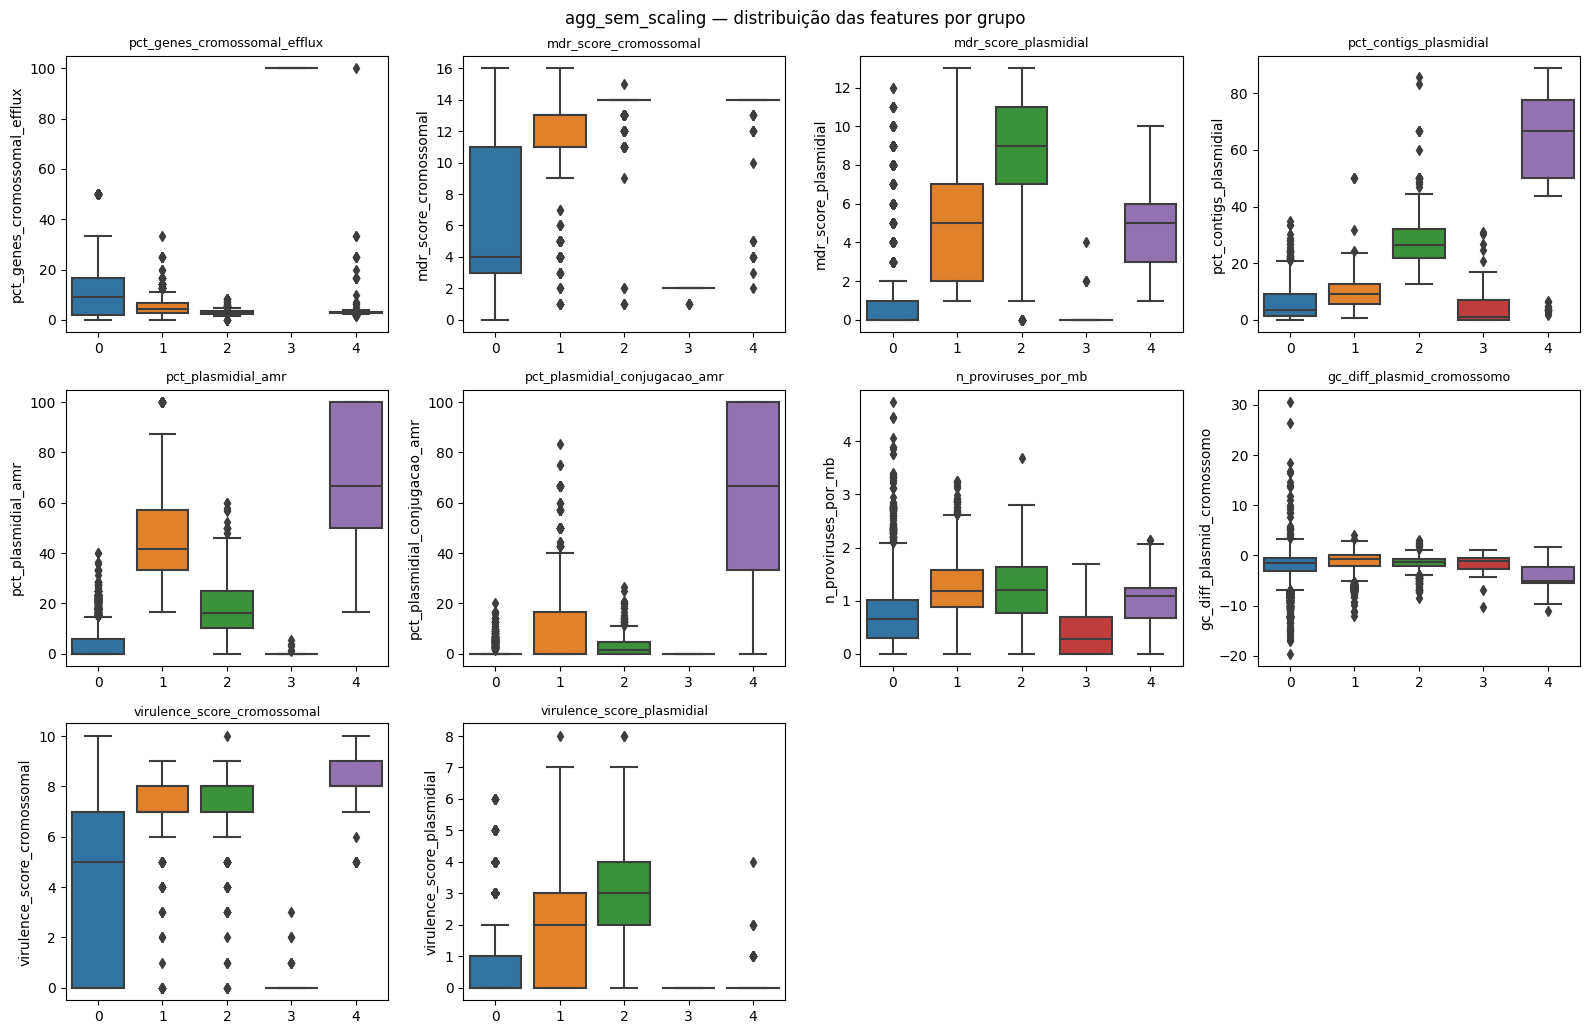


agg_minmax
0     942
1    1064
2     697
3    1091
4     807
5     325
Name: agg_minmax, dtype: int64


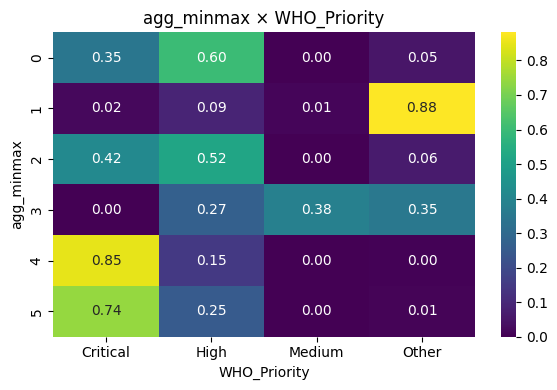

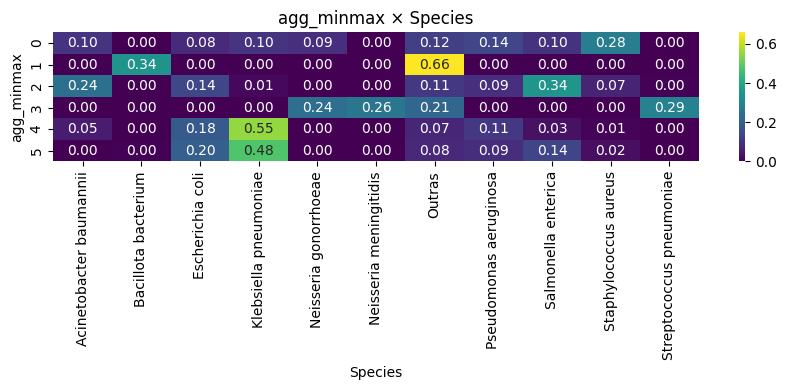

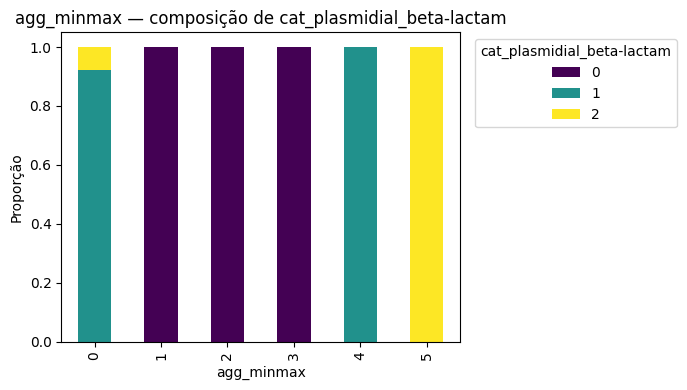

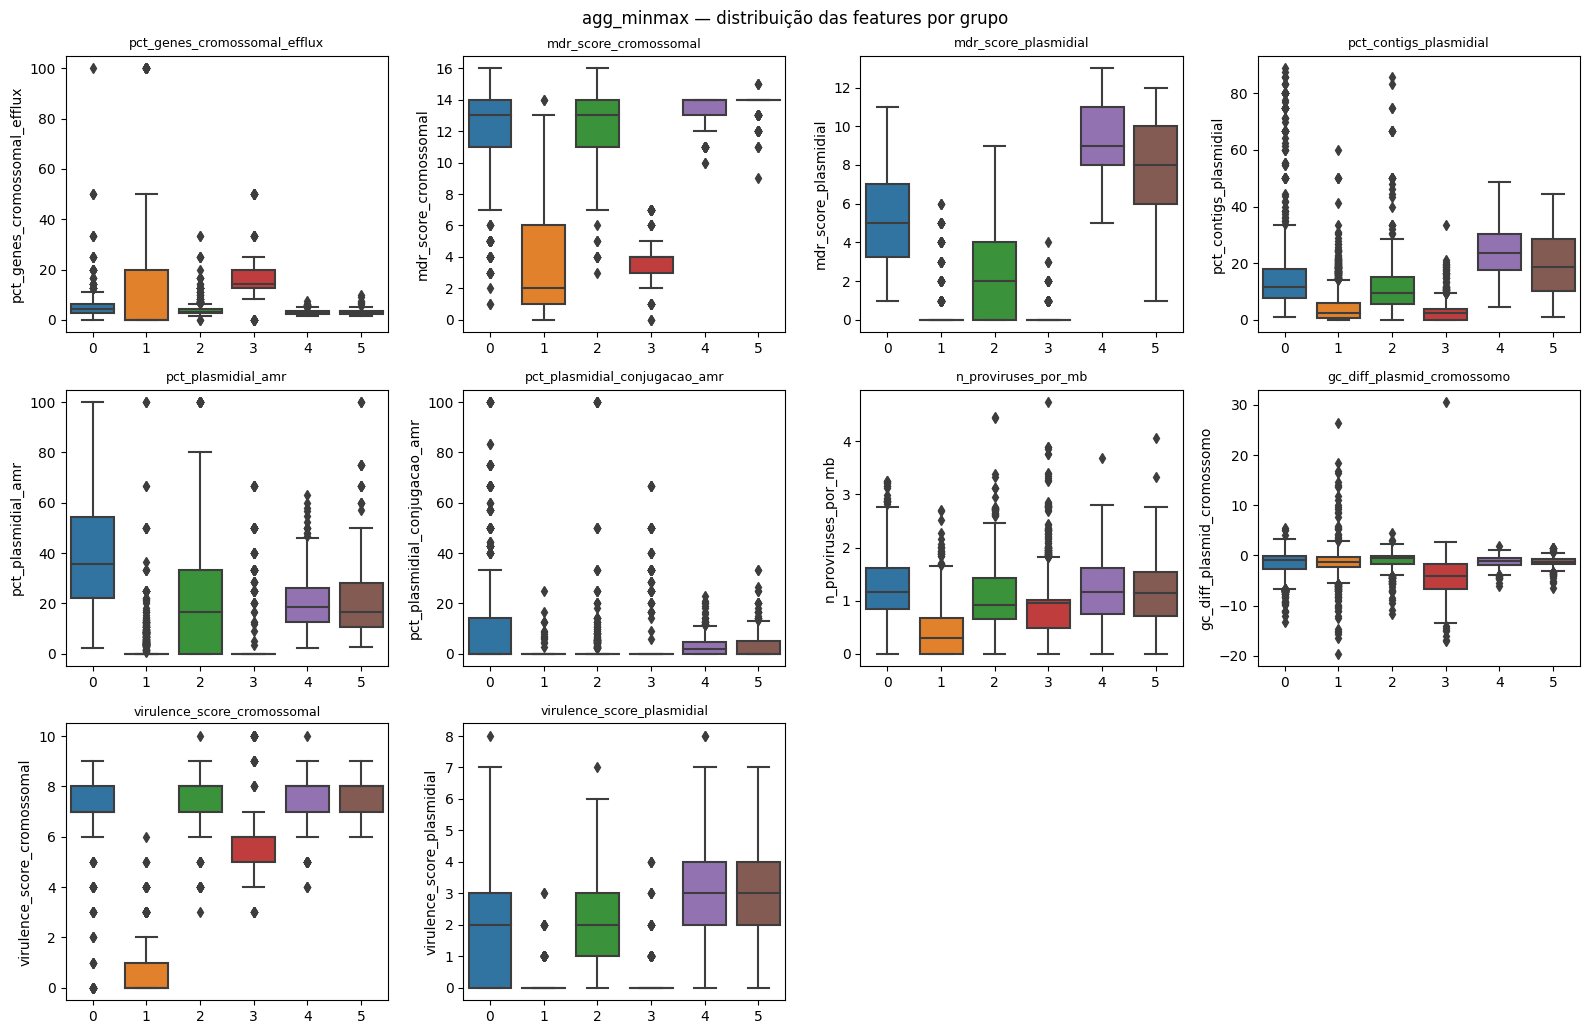

In [254]:
for cluster_col in colunas_cluster:
    diagnosticar_cluster(
        cluster_col, df_train, metadata_alinhado, especie_plot_completo,
        colunas_numericas=colunas_numericas,
        colunas_ordinais=["cat_plasmidial_beta-lactam"],
    )